# Imports and Functions


In [1]:

import datetime as dt
import numpy as np
import math as M
import glob
import os
import re
import xarray as xr
import pandas as pd
import json
import scipy


import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker

from matplotlib.colors import LinearSegmentedColormap, to_rgb
import matplotlib.patheffects as path_effects
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.transforms as transforms
import matplotlib.patches as patches

#from matplotlib.offsetbox import AnchoredText
import skimage.measure as sm
from scipy import stats
import scipy.ndimage as ndimage
from scipy.ndimage import gaussian_filter

import colormaps as cmaps

def findnearest(array, value):
    array = np.asarray(array)
    return (np.abs(array-value)).argmin()

#mpl.rcParams.keys()
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0, 'lines.solid_capstyle':'butt',
                     'axes.labelsize':13, 'axes.titlesize':18, 'ytick.labelsize':13, 'xtick.labelsize':13, 'axes.titleweight':'bold'})


def pmm(cm1, var, height,t, return_mean=False):
    ''' height is in km'''

    N = cm1.sizes['ne']-1
    zi = findnearest(cm1.z, height)

    ens_mean = cm1[var][t, -1,zi]
    ranked_ens =sorted(cm1[var][t, :-1, zi].values.ravel())[::N]
    
    x,y = np.meshgrid(cm1.xh, cm1.yh)
    d = {'ens':ens_mean.values.ravel(), 'x':x.ravel(), 'y':y.ravel()}
    df = pd.DataFrame(d)
    
    df_ranked = df.sort_values(by='ens')
    df_ranked['ens'] = ranked_ens
    
    df_pmm = df_ranked.sort_index()

    if return_mean:
    
        return df_pmm['ens'].values.reshape(np.shape(x)), ens_mean
    else:
        return df_pmm['ens'].values.reshape(np.shape(x))

    
def add_scale(ax, xstart=200, xlength=50, y=280, cap_length=200*.04, text_bump =0):

    xend = xstart+xlength
    
    ax.plot([xstart,xend], [y,y], color='k')
    ax.plot([xstart,xstart], [y-cap_length/2,y+cap_length/2], color='k')
    ax.plot([xend, xend], [y-cap_length/2,y+cap_length/2], color='k')
    #ax.text(xstart+xlength/2, y-cap_length/2, '{xlength} km', ha='center', va='top', fontsize=13)
    ax.text(xstart+xlength/2, text_bump+y+cap_length/2, f'{xlength} km', ha='center', va='bottom', fontsize=13)


def add_subplot_labels(ax, i, x=0, y=0, fontsize=18, weight='normal', lw = 5):
    ax.text(x, y,  chr(ord('`')+i+1)+')', va='top', fontsize=fontsize, fontweight=weight, transform=ax.transAxes,
             path_effects=[path_effects.Stroke(linewidth=lw, foreground='white'),path_effects.Normal()], zorder=500)

def performance_diagram(ax, axis_labels=True, colorbar_auto=False, cax = None, cbar_fs = 13, return_colorbar_info = True, bias_label_size = 10, version='Full'):

    ax.set_aspect('equal')
    ax.set_xlim(0,1.)
    ax.set_ylim(0,1.)
    
    sr_array = np.linspace(0.001,1,200)
    pod_array = np.linspace(0.001,1,200)
    X,Y = np.meshgrid(sr_array,pod_array)
    csi_vals = (X** -1 + Y ** -1 - 1.) ** -1 
    im = ax.contourf(X,Y,csi_vals,levels=np.arange(0,1.1,0.1),cmap='Greys', alpha=0.3, antialiased=True, zorder=0) #blue_blgra2_r,
    ax.contour(X,Y,csi_vals, levels=[0.2, 0.5, 0.8], colors='0.5', alpha=0.3)

    if version == 'Full':

        fb = Y/X #X/Y
        ax.contour(X,Y,fb,levels=[1],linestyles='--',colors='0.5', linewidths=1)
        bias = ax.contour(X,Y,fb,levels=[0.1,0.5,1,1.5,2,3,5,10],linestyles='--',colors='Grey', linewidths=0.5)
        plt.clabel(bias, inline=True, inline_spacing=2,fmt='%.1f', fontsize=bias_label_size,colors='0.3')

    if colorbar_auto:
        cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('Critical Success Index (CSI)', weight='bold', fontsize=cbar_fs)
        [cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]]
    if cax != None:
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Critical Success Index (CSI)', weight='bold', fontsize=cbar_fs)
        [cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]]
        
    if axis_labels:
        ax.set_xlabel('Success Ratio (1-FAR)')
        ax.set_ylabel('POD')

    if return_colorbar_info:
        return im

def open_exp(path, fcst_start=False):
    fpath = os.path.join(path ,'letkf.exp' )
    if os.path.exists(fpath):
        with open(fpath, 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['DA_PARAMS']['DA_end_time'],'%Y-%m-%d %H:%M:%S')
    else:
        with open(os.path.join(path, 'fcst.exp' ), 'rb') as f: exper = json.load(f)
        if fcst_start: f_start = dt.datetime.strptime(exper['FORECAST']['start'],'%Y-%m-%d %H:%M:%S')

    if fcst_start:
        return exper, f_start
    else:
        return exper

def calc_csi(X, Y):
    return (X** -1 + Y ** -1 - 1.) ** -1 


def rename(exp, version = 'RAW'):
    '''versions are FUll,FULLX, H, V, CI, or RAW'''
    version = version.upper()
    
    if (exp!= 'Control') & (version !='RAW'):
    
        split = exp.split('_')
        ci = split[0]
        hloc = split[1]
        vloc = split[2]
    
        if hloc=='H07':hloc='H7.5'
        #if hloc==9:hloc='9.0'
        
        extra = ''
        if len(split) > 3:extra = f'-{split[3]}'

        if version=='FULLX': name = f'{ci}-{hloc}-{vloc}.5{extra}'
        if version=='FULL':  name = f'{ci}-{hloc}-{vloc}.5'
        if version=='H':     name = f'{ci}-{hloc}'
        if version=='V':     name = f'{ci}-{vloc}.5'
        if version=='CI':    name = f'{ci}'
            
    else:
        if exp == 'Control': name = 'No DA'
        else: name = exp    
    return name

import sys
sys.path.append('src/plot_src/')
from ColorblindFilter import colorblind_filter
#import wofs_cbook_nowrf as wofs


import numpy as np
from numba import njit, prange

import netCDF4



def generate_bootstrap_indices(n_vals,max_index, n_boot, seed=0):
    rng = np.random.default_rng(seed)
    return rng.integers(0, max_index, size=(n_boot, n_vals))
    
@njit(parallel=True)
def bootstrap_contigency(hits, misses, false_alarms, indices):
    n_boot, n = indices.shape

    csi_vals  = np.empty(n_boot)
    pod_vals  = np.empty(n_boot)
    far_vals  = np.empty(n_boot)
    bias_vals = np.empty(n_boot)

    for i in prange(n_boot):
        h = 0.0
        m = 0.0
        f = 0.0

        for j in range(n):
            idx = indices[i, j]
            h += hits[idx]
            m += misses[idx]
            f += false_alarms[idx]

        denom_csi = h + m + f
        denom_pod = h + m
        denom_far = h + f

        csi_vals[i] = h / denom_csi        if denom_csi > 0 else np.nan
        pod_vals[i] = h / denom_pod        if denom_pod > 0 else np.nan
        bias_vals[i] = (h + f) / denom_pod if denom_pod > 0 else np.nan
        far_vals[i] = f / denom_far        if denom_far > 0 else np.nan

    return csi_vals, pod_vals, far_vals, bias_vals


@njit(parallel=True)
def bootstrap_contigency_bothfcsts(h1,h2, m1, m2, fa1, fa2, indices):
    n_boot, n = indices.shape

    csi_vals  = np.empty(n_boot)
    pod_vals  = np.empty(n_boot)
    far_vals  = np.empty(n_boot)
    bias_vals = np.empty(n_boot)

    for i in prange(n_boot):
        h = 0.0
        m = 0.0
        f = 0.0

        for j in range(n):
            idx = indices[i, j]
            h += h1[idx] + h2[idx]
            m += m1[idx] + m2[idx]
            f += fa1[idx] + fa2[idx]

        denom_csi = h + m + f
        denom_pod = h + m
        denom_far = h + f

        csi_vals[i] = h / denom_csi        if denom_csi > 0 else np.nan
        pod_vals[i] = h / denom_pod        if denom_pod > 0 else np.nan
        bias_vals[i] = (h + f) / denom_pod if denom_pod > 0 else np.nan
        far_vals[i] = f / denom_far        if denom_far > 0 else np.nan

    return csi_vals, pod_vals, far_vals, bias_vals

@njit(parallel=True)
def bootstrap_singlevar(fss, indices):
    n_boot, n = indices.shape

    fss_vals = np.empty(n_boot)

    for i in prange(n_boot):
        s = 0.0

        for j in range(n):
            idx = indices[i, j]
            s += fss[idx]

        fss_vals[i] = s / n  # mean FSS for this resample

    return fss_vals

@njit(parallel=True)
def bootstrap_singlevar_bothfcsts(fss1,fss2, indices):
    n_boot, n = indices.shape

    fss_vals = np.empty(n_boot)

    for i in prange(n_boot):
        s = 0.0

        for j in range(n):
            idx = indices[i, j]
            s += fss1[idx]+fss2[idx]

        fss_vals[i] = s / (2*n)  # mean FSS for this resample, times 2 because I didn't average both forecasts yet

    return fss_vals


def get_universal_bca(data1, boot_metrics, obs_metrics, data2=None, mode='contingency', operation='single', return_jack=False):
    """
    Calculates 95% BCa confidence intervals for multiple ensemble verification scenarios
    using pre-calculated bootstrap metrics.
    
    Parameters:
    -----------
    data1 : numpy array
        Array of shape (N, 3) for contingency or (N,) for single_var.
    boot_metrics : numpy array
        Pre-calculated bootstrap metrics/differences. Shape (n_iterations, M).
    obs_metrics : numpy array or float
        The observed aggregate metrics/differences. Shape (M,) or float.
    data2 : numpy array, optional
        The second forecast array. Required if operation is 'difference' or 'combined'.
    mode : str
        Either 'contingency' or 'single_var'.
    operation : str
        'single' (evaluates data1)
        'difference' (evaluates data2 - data1)
        'combined' (evaluates aggregate of data1 + data2)
    return_jack : bool
        If True, includes raw jackknife arrays in the output.
        
    Returns:
    --------
    results : dict
        Observed values, bounds, and significance flags (if operation == 'difference').
    """
    n_members = len(data1)
    eps = 1e-10
    
    if operation in ['difference', 'combined'] and data2 is None:
        raise ValueError("data2 must be provided when operation is 'difference' or 'combined'.")
        
    # Standardize array shapes
    boot_metrics = np.array(boot_metrics)
    if boot_metrics.ndim == 1:
        boot_metrics = boot_metrics.reshape(-1, 1)
        
    obs_metrics = np.atleast_1d(obs_metrics)
    n_iterations = len(boot_metrics)

    # --- 1. Universal Aggregation Engine ---
    if mode == 'contingency':
        metric_names = ['POD', 'SR', 'BIAS', 'CSI']
        
        def _get_contingency(counts):
            """Helper to convert [Hits, Misses, FA] into metrics"""
            h, m, fa = counts[0], counts[1], counts[2]
            pod = h / (h + m + eps)
            sr = h / (h + fa + eps) # Success Ratio
            bias = (h + fa) / (h + m + eps)
            csi = h / (h + m + fa + eps)
            return np.array([pod, sr, bias, csi])

        def calc_stat(d1, d2=None):
            if operation == 'single':
                return _get_contingency(np.sum(d1, axis=0))
            elif operation == 'difference':
                m1 = _get_contingency(np.sum(d1, axis=0))
                m2 = _get_contingency(np.sum(d2, axis=0))
                return m2 - m1
            elif operation == 'combined':
                # Sum the raw counts from both forecasts, then calculate metrics
                combined_counts = np.sum(d1, axis=0) + np.sum(d2, axis=0)
                return _get_contingency(combined_counts)

    elif mode == 'single_var':
        metric_names = ['Value'] 
        
        def calc_stat(d1, d2=None):
            if operation == 'single':
                return np.array([np.mean(d1)])
            elif operation == 'difference':
                return np.array([np.mean(d2) - np.mean(d1)])
            elif operation == 'combined':
                # Average across both sets of members
                return np.array([np.mean(np.concatenate([d1, d2]))])
                
    else:
        raise ValueError("Mode must be either 'contingency' or 'single_var'.")

    # --- 2. Jackknife (for Acceleration 'a') ---
    jack_stats = []
    for i in range(n_members):
        d1_temp = np.delete(data1, i, axis=0)
        d2_temp = np.delete(data2, i, axis=0) if data2 is not None else None
        jack_stats.append(calc_stat(d1_temp, d2_temp))
    
    jack_stats = np.array(jack_stats)
    mean_jack = np.mean(jack_stats, axis=0)
    
    # d is the difference between the average jackknife and each specific one
    d = mean_jack - jack_stats
    
    # Acceleration constant (a)
    a_coeffs = np.sum(d**3, axis=0) / (6 * (np.sum(d**2, axis=0)**1.5) + eps)

    # --- 3. Final BCa Intervals ---
    results = {}
    z_alpha = 1.96  # for 95% CI

    for i, name in enumerate(metric_names):
        # Bias Correction (z0)
        p = np.count_nonzero(boot_metrics[:, i] < obs_metrics[i]) / n_iterations
        p = np.clip(p, 0.0001, 0.9999) 
        z0 = scipy.stats.norm.ppf(p)
        
        # Adjusted percentiles
        num_low = z0 - z_alpha
        w_low = z0 + num_low / (1 - a_coeffs[i] * num_low)
        
        num_high = z0 + z_alpha
        w_high = z0 + num_high / (1 - a_coeffs[i] * num_high)
        
        p_low = scipy.stats.norm.cdf(w_low)
        p_high = scipy.stats.norm.cdf(w_high)
        
        # Retrieve bounds from sorted bootstrap distribution
        sorted_boot = np.sort(boot_metrics[:, i])
        
        low_idx = np.clip(int(p_low * n_iterations), 0, n_iterations - 1)
        high_idx = np.clip(int(p_high * n_iterations), 0, n_iterations - 1)
        
        lower_bound = sorted_boot[low_idx]
        upper_bound = sorted_boot[high_idx]
        obs_val = obs_metrics[i]
        
        results[name] = {
            'obs': obs_val,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        
        # Apply Significance logic ONLY for differences
        if operation == 'difference':
            if obs_val < lower_bound or obs_val > upper_bound:
                sig = 999
            elif lower_bound > 0:
                sig = 1
            elif upper_bound < 0:
                sig = -1
            else:
                sig = 0
            results[name]['sig'] = sig
            
        if return_jack:
            results[name]['jack_stats'] = jack_stats[:, i]
            
    return results

def _safe_ratio(num, den):
    den = float(den)
    if den == 0.0:
        den = 1e-10
    return float(num) / den

def get_cont_table(sa,sb,sc):
    '''hits, false alarms, misses'''

    pod = _safe_ratio(sa, sa + sc)        #  POD          
    sr = 1 - _safe_ratio(sb, sa + sb)       #  SUCCESS RATIO (1-FAR)
    csi = calc_csi(pod, sr)  #  CRITICAL SUCCESS INCDEX
    bias = _safe_ratio(pod, sr)          #  BIAS (POD/ SR)
    
    return {'POD':pod, 'SR': sr, 'CSI':csi, 'BIAS':bias}


def generate_CI_FSS(exp, var, neighborhood=24, fcsts=[''], fcst_diff = False, thresh=None, interval = 95, indices= [], plot_test = False):
    '''if fcst_diff = true, then the fss_val (first returned value) is a list, first value is the mean fss, second value is the key for if the forecasts are significantly different '''

    fcsts = np.atleast_1d(fcsts)

    if (var== 'UH' ):
        if (thresh == None):
            thresh = 99.9
        th_i = findnearest(np.array([99.75,99.85, 99.90, 99.95, 99.99]), thresh)

    elif (var == 'cdbz'):
        if (thresh == None):
            thresh = 98.0
        th_i = findnearest(np.array([95.0, 97.0, 98.0, 99.0, 99.5]), thresh)
    


    indices = generate_bootstrap_indices(36, 36, 10000, seed=42)
        


    fss = np.zeros([len(fcsts), 36])
    
    for f,fcst in enumerate(fcsts):

        ds = xr.open_dataset(os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcst, f'fss_{var}.nc' ))
        n_i = findnearest(ds.SCALES.values*1000, neighborhood)
        fss[f, :] = np.mean(ds.FSS[:,-13:,n_i, th_i].values, axis=1)
        ds.close()


    if len(fcsts) == 1:
        boot_metrics = bootstrap_singlevar(np.array(fss).flatten(), indices)
        results = get_universal_bca(fss.flatten(), boot_metrics, np.mean(fss), mode='single_var', operation='single')

    if len(fcsts) == 2:
        boot_metrics = bootstrap_singlevar_bothfcsts(np.array(fss[0]).flatten(),np.array(fss[1]).flatten(), indices)
        results = get_universal_bca(fss[0].flatten(), boot_metrics, np.mean(fss), data2=fss[1].flatten(), mode='single_var', operation='combined')

    
    if fcst_diff == False:
        
        return results['Value']['obs'], results['Value']['lower_bound'], results['Value']['upper_bound']

    else:
        indices1 = generate_bootstrap_indices(36, 36, 10000, seed=420)
 

        # fss1 = bootstrap_fss_from_indices(np.array(fss[0]).flatten(), indices1)
        # fss2 = bootstrap_fss_from_indices(np.array(fss[1]).flatten(), indices1)
        # boot_metrics = bootstrap_fss_from_indices(fss2 - fss1, indices)


        fss1 = bootstrap_singlevar(np.array(fss[0]).flatten(), indices1)
        fss2 = bootstrap_singlevar(np.array(fss[1]).flatten(), indices1)
        boot_metrics = bootstrap_singlevar(fss2 - fss1, indices)

        obs_metrics  = np.mean(fss[1,:] - fss[0,:])

        results_diff = get_universal_bca(fss[0].flatten(), boot_metrics, obs_metrics, data2=fss[1].flatten(), mode='single_var', operation='difference')


        return results['Value']['obs'], results['Value']['lower_bound'], results['Value']['upper_bound'], results_diff['Value']['sig']


def generate_CI_contigency(exp, var, fcsts=[''], fcst_diff = False, thresh=None,  plot_test = False):
    ''' if you use fcst_diff == True, then each val_dict variable will be a list, [variable, sig] where sig is a key for whether fcst 2 > fcst 1 (0 is no diff, -1 is worse, 1 is better)'''


    ci_dict = {}
    val_dict = {}

    
    fcsts = np.atleast_1d(fcsts)
    
    # create indices to use
    indices = generate_bootstrap_indices(36, 36, 10000, seed=42)
    
    if (var.upper() == 'UH' )& (thresh == None):
        thresh = 99.9
    elif (var == 'cdbz') & (thresh == None):
        thresh = 98.0
    

    # for anything bca related, use the following order = ['POD', 'SR', 'BIAS', 'CSI']

    ### read in data 
    hits,misses,fas = np.zeros(36*len(fcsts)),np.zeros(36*len(fcsts)),np.zeros(36*len(fcsts))
    for f,fcst in enumerate(fcsts):
        perf = xr.open_dataset(os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcst, f'performance_{var}_p{thresh}.nc' ))
    
        ap,bp,cp = perf['hits'].values, perf['false_alarms'].values,perf['misses'].values
        
        hits[0+(36*f): 36+(36*f)]   = np.sum(ap, axis=0) 
        fas[0+(36*f): 36+(36*f)]    = np.sum(bp, axis=0) 
        misses[0+(36*f): 36+(36*f)] = np.sum(cp, axis=0)
        perf.close()
    
    
    ###### SINGLE FORECAST
    if len(fcsts) == 1: 
    
        # bootstrap
        csi_vals, pod_vals, far_vals, bias_vals = bootstrap_contigency(np.array(hits).flatten(),np.array(misses).flatten(),np.array(fas).flatten(),indices)
    
        # prep data and find bounds
        agg_cont = get_cont_table(hits.sum(), fas.sum(), misses.sum())
        obs_metrics = [agg_cont['POD'], agg_cont['SR'], agg_cont['BIAS'], agg_cont['CSI']]
        boot_metrics = np.array(list(zip(pod_vals, 1-far_vals, bias_vals, csi_vals))) 
        
        results = get_universal_bca(np.array(list(zip(hits,misses, fas))), boot_metrics, obs_metrics, mode='contingency', operation='single')
    
        # fill in dictionaries
        for cont_metric in ['POD', 'BIAS', 'SR', 'CSI']: 
            ci_dict[cont_metric] = [results[cont_metric]['lower_bound'], results[cont_metric]['upper_bound']] # now fill the dictionary that I'll return later
            val_dict[cont_metric] = [results[cont_metric]['obs']]
            
    ###### BOTH FORECASTS    
    if len(fcsts) == 2: 
    
        # split data up 
        h1,h2, m1,m2, fa1, fa2  = hits[0:36],hits[36:],  misses[0:36],misses[36:],  fas[0:36],fas[36:]
        f1_counts = np.array(list(zip(h1,m1,fa1)))
        f2_counts = np.array(list(zip(h2,m2,fa2)))
    
        # bootstrap both forecasts
        csi_vals, pod_vals, far_vals, bias_vals = bootstrap_contigency_bothfcsts(h1,h2, m1, m2, fa1, fa2, indices)
    
        # prep data and find bounds
        agg_cont = get_cont_table(hits.sum(), fas.sum(), misses.sum())
        obs_metrics = [agg_cont['POD'], agg_cont['SR'], agg_cont['BIAS'], agg_cont['CSI']]
        boot_metrics = np.array(list(zip(pod_vals, 1-far_vals, bias_vals, csi_vals))) ##### ORDER IS VERY IMPORTANT!
        
        results = get_universal_bca(f1_counts, boot_metrics, obs_metrics, data2=f2_counts, mode='contingency', operation='combined')
    
        # fill in dictionaries
        for cont_metric in ['POD', 'BIAS', 'SR', 'CSI']: 
            ci_dict[cont_metric] = [results[cont_metric]['lower_bound'], results[cont_metric]['upper_bound']] # now fill the dictionary that I'll return later
    
        
        for VAR in ['POD', 'SR', 'BIAS', 'CSI']: val_dict[VAR] =[results[VAR]['obs']]
                
    
    
        if (fcst_diff == True): 
        
            # now find out if the CSI is signficiantly different between the forecasts 
            indices1 = generate_bootstrap_indices(36, 36, 10000, seed=420)
        
        
            # calculate the difference in metrics
            f1cont = get_cont_table(h1.sum(), fa1.sum(), m1.sum())
            f2cont = get_cont_table(h2.sum(), fa2.sum(), m2.sum())
        
            # IMPORTANT ORDER
            obs_metrics = [f2cont['POD']  - f1cont['POD'],
                           f2cont['SR']   - f1cont['SR'],
                           f2cont['BIAS'] - f1cont['BIAS'],
                           f2cont['CSI']  - f1cont['CSI']] 
        
         
            # now find 10000 samples of potential CSI values
            csi_vals1, pod_vals1, far_vals1, bias_vals1 = bootstrap_contigency(np.array(h1).flatten(), np.array(m1).flatten(), np.array(fa1).flatten(),indices1)
            csi_vals2, pod_vals2, far_vals2, bias_vals2= bootstrap_contigency(np.array(h2).flatten(), np.array(m2).flatten(), np.array(fa2).flatten(),indices1)
        
            # IMPORTANT ORDER
            boot_metrics = np.array(list(zip(pod_vals2 - pod_vals1, 
                                        (1-far_vals2) - (1-far_vals1), 
                                        bias_vals2 - bias_vals1, 
                                        csi_vals2 - csi_vals1)))
        
            results = get_universal_bca(f1_counts, boot_metrics, obs_metrics, data2=f2_counts, mode='contingency', operation='difference')
    

            # fill in dictionaries
            for VAR in ['POD', 'SR', 'BIAS', 'CSI']: ci_dict[VAR+'_sig'] = results[VAR]['sig']
        
                
        
            if plot_test:
                
     
                fig, axes = plt.subplots(1,3, figsize=(20, 6))
                axes[0].hist(csi_vals, bins=50);
                axes[0].axvline(ci_dict['CSI'][0], alpha=0.3, lw=3, color='C3')
                axes[0].axvline(ci_dict['CSI'][1], alpha=0.3, lw=3, color='C3')
        
                axes[0].axvline(val_dict['CSI'][0], color='b',  lw=3,)
                axes[0].axvline(np.mean(csi_vals), color='k', alpha=0.3, lw=3, ls='--')
                
                axes[0].set_title(f'{exp}, {var}')
        
                axes[0].set_xlim(0, 1)
        
        
                axes[1].hist(csi_vals1, bins=50, color='C0', alpha=0.4);
                axes[1].hist(csi_vals2, bins=50, color='C2', alpha=0.4);
                axes[1].axvline(csi_vals1.mean(),color='C0', alpha=0.3, lw=3, ls='--')
                axes[1].axvline(csi_vals2.mean(),color='C2', alpha=0.3, lw=3, ls='--')
        
                axes[1].axvline(f1cont['CSI'],color='C0', alpha=0.3, lw=3)
                axes[1].axvline(f2cont['CSI'],color='C2', alpha=0.3, lw=3)
        
                axes[1].set_xlim(0,1)
        
        
                axes[2].hist(boot_metrics[:,-1], bins=50)
                axes[2].axvline(obs_metrics[-1], color='b', lw=3)
                axes[2].axvline(np.mean(boot_metrics[:,-1]), color='k', lw=3, alpha=0.3, ls='--')
                
                axes[2].axvline(0, lw = 4, color='k', ls='--')
                axes[2].axvline(results['CSI']['lower_bound'], alpha=0.8, lw=3, color='C3')
                axes[2].axvline(results['CSI']['upper_bound'], alpha=0.8, lw=3, color='C3')
        
                axes[2].set_title(f"{exp}, {var}, {results['CSI']['sig']}")
        
                #[axes[2].axvline(ctemp, color='C0' , lw=0.5, alpha=0.5) for ctemp in jack_diffs]
    
                plt.show()
        
           
    return val_dict, ci_dict 


def centered_on_axes(axes, ai, version='inbetween'):
    ''' if version is inbetween, returns the location directly in between two axes objects for text placement, ai is the index of the top axis.
    otherwise, if version is on, then it gives the cetner of the given index'''

    if version == 'inbetween':
        bbox1 = axes[ai, -1].get_position()
        bbox2 = axes[ai+1, -1].get_position()
        
        bot = bbox1.y0
        top = bbox2.y0 + bbox2.height
        xloc = bbox2.x0 + bbox2.width
    
        return xloc, (bot+top)/2
    else:
        bbox1 = axes[ai, -1].get_position()
        xloc = bbox1.x0 + bbox1.width
    
        return xloc, bbox1.y0 + (bbox1.height/2)





# Probability Swath Plots

In [8]:
import numpy as np
from numba import njit, prange

def get_1d_gaussian_kernel(sigma, truncate=4.0):
    """Generates a 1D Gaussian kernel matching Scipy's default truncation."""
    if sigma <= 0:
        return np.array([1.0])
    radius = int(truncate * sigma + 0.5)
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)
    kernel /= np.sum(kernel) # Normalize
    return kernel

@njit(parallel=True, fastmath=True)
def fast_4d_gaussian_filter(data, kernel):
    """
    Applies a separable 2D Gaussian filter to a 4D array (time, member, y, x).
    Parallelized across the time dimension.
    """
    nt, nmem, ny, nx = data.shape
    radius = len(kernel) // 2
    
    # Pre-allocate temporary and output arrays
    temp = np.empty_like(data)
    out = np.empty_like(data)
    
    # --- Pass 1: X-direction (Horizontal smoothing) ---
    for t in prange(nt):
        for m in range(nmem):
            for y in range(ny):
                for x in range(nx):
                    val = 0.0
                    for k in range(-radius, radius + 1):
                        ix = x + k
                        
                        # Boundary handling: 'reflect' (mirror)
                        if ix < 0:
                            ix = -ix
                        elif ix >= nx:
                            ix = 2 * nx - 2 - ix
                            
                        val += data[t, m, y, ix] * kernel[k + radius]
                    temp[t, m, y, x] = val
                    
    # --- Pass 2: Y-direction (Vertical smoothing) ---
    for t in prange(nt):
        for m in range(nmem):
            for y in range(ny):
                for x in range(nx):
                    val = 0.0
                    for k in range(-radius, radius + 1):
                        iy = y + k
                        
                        # Boundary handling: 'reflect' (mirror)
                        if iy < 0:
                            iy = -iy
                        elif iy >= ny:
                            iy = 2 * ny - 2 - iy
                            
                        val += temp[t, m, iy, x] * kernel[k + radius]
                    out[t, m, y, x] = val
                    
    return out

# import numpy as np
# from numba import njit, prange

@njit(parallel=True, fastmath=True)
def fast_4d_max_filter_3x3(data):
    """
    Applies a 3x3 maximum filter (grey dilation) to the spatial dimensions (y, x)
    of a 4D array (time, member, y, x). Parallelized across the time dimension.
    """
    nt, nmem, ny, nx = data.shape
    out = np.empty_like(data)
    
    # --- Loop over time (parallelized) and members ---
    for t in prange(nt):
        for m in range(nmem):
            
            # --- Loop over spatial grid ---
            for y in range(ny):
                for x in range(nx):
                    
                    # Initialize the max value with the center pixel
                    max_val = data[t, m, y, x]
                    
                    # Search the 3x3 box (dy and dx range from -1 to 1)
                    for dy in range(-1, 2):
                        for dx in range(-1, 2):
                            
                            # Skip the center pixel since we already initialized with it
                            if dy == 0 and dx == 0:
                                continue
                                
                            iy = y + dy
                            ix = x + dx
                            
                            # Boundary handling: 'reflect' (mirror) to match Scipy defaults
                            if iy < 0:
                                iy = -iy
                            elif iy >= ny:
                                iy = 2 * ny - 2 - iy
                                
                            if ix < 0:
                                ix = -ix
                            elif ix >= nx:
                                ix = 2 * nx - 2 - ix
                                
                            # Update max_val if a larger value is found
                            val = data[t, m, iy, ix]
                            if val > max_val:
                                max_val = val
                                
                    # Assign the absolute local maximum to the output array
                    out[t, m, y, x] = max_val
                    
    return out


@njit(parallel=True, fastmath=True)
def fast_swath_probability(data, threshold, divisor):
    """
    Calculates the ensemble probability of exceeding a threshold at any point in time.
    data shape: (time, member, y, x)
    """
    nt, nmem, ny, nx = data.shape
    
    # Pre-allocate just the final 2D output array (y, x)
    out = np.empty((ny, nx), dtype=np.float32)
    
    # Parallelize across the Y-axis
    for y in prange(ny):
        for x in range(nx):
            exceed_count = 0
            
            for m in range(nmem):
                # Check if this member exceeded the threshold at ANY time
                for t in range(nt):
                    if data[t, m, y, x] >= threshold:
                        exceed_count += 1
                        break  # Short-circuit! Move immediately to the next member
                        
            # Calculate the final percentage for this grid point
            out[y, x] = 100.0 * exceed_count / divisor
            
    return out


def get_probability_swath(myvar, ens_threshold, n=36):
    kernel_1d = get_1d_gaussian_kernel(2.0, truncate=4.0)
    max_3x3 = fast_4d_max_filter_3x3(myvar)
    smooth= fast_4d_gaussian_filter(max_3x3, kernel_1d)
    return fast_swath_probability(smooth, ens_threshold, n)



def plot_setup(n):
    if n == 9:
        fig, axes = plt.subplots(3, n, figsize=(30, 9), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})
        cbar_width = 0.01

    if n == 7:
        fig, axes = plt.subplots(3, n, figsize=(26, 15), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})
        cbar_width = 0.01
        plt.subplots_adjust(hspace=0.02, wspace=0.06)


    if n == 6:
        fig, axes = plt.subplots(3, n, figsize=(23, 12), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})
        cbar_width = 0.02

    if n == 5:
        fig, axes = plt.subplots(3, n, figsize=(20, 13), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})
        cbar_width = 0.015
        plt.subplots_adjust(hspace=0.015, wspace=0.04)
        

    if n == 4:
        fig, axes = plt.subplots(3, n, figsize=(14, 11), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})
        cbar_width = 0.02
        plt.subplots_adjust(hspace=0.02, wspace=0.06)

    if n == 3:
        cbar_width = 0.02
        fig, axes = plt.subplots(3, n, figsize=(12, 12), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})#, facecolor='none')
        plt.subplots_adjust(hspace=0.06, wspace=0.04)

    if n == 2:
        cbar_width = 0.02
        fig, axes = plt.subplots(3, n, figsize=(8, 12), sharex='row', sharey='row', subplot_kw={'aspect':'equal'})#, facecolor='none')
        plt.subplots_adjust(hspace=0.06, wspace=0.04)

    return fig, axes, cbar_width

def probability_colormap():
    cmap_b = cmaps.sunburst_r.cut(.2, 'right')
    clist = [to_rgb('#ffffff')]
    clist.extend(cmap_b(np.linspace(0,1,49)))
    cmap1 = LinearSegmentedColormap.from_list("CR", clist, 30)
    return cmap1

def add_CI_boxes(exp, var, thresh, fcst, ax, color, texty=0.16, add=''):

    val_dct, ci_dct = generate_CI_contigency(exp,var, fcsts=fcst, thresh=thresh)
    y0, y1 = ci_dct['POD'][0],ci_dct['POD'][1]
    x0, x1 = ci_dct['SR'][0] ,ci_dct['SR'][1]
    corners = [(x0, y0), (x1, y0), (x1, y1), (x0, y1)]
    rect1 = patches.Polygon(corners, facecolor=np.concatenate((color[0:-1], np.array([0.3]))),edgecolor=np.concatenate((color[0:-1], np.array([0.6]))), linewidth=1)
    ax.add_patch(rect1)

    ax.scatter(val_dct['SR'][0], val_dct['POD'][0], color=color, zorder=102, marker='s', s=8)

    bbox = dict(facecolor='white', alpha=1.0, edgecolor='none', pad=3)

    ax.text(0.03, texty, f"{add}CSI: {val_dct['CSI'][0]:.2f}", color=color, ha='left', va='top', weight='bold', zorder=101, fontsize=13,bbox=bbox )




0 C15_H18_V6_fine
no forecast for C15_H18_V6_fine, FORECAST_20240508_2100
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H18_V6_fine/FORECAST_20240508_2100/performance_UH_p99.9.nc
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H18_V6_fine//performance_UH_p99.9.nc
1 C15_H15_V4_fine
no forecast for C15_H15_V4_fine, FORECAST_20240508_2100
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H15_V4_fine/FORECAST_20240508_2100/performance_UH_p99.9.nc
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H15_V4_fine//performance_UH_p99.9.nc
2 C15_H12_V4_fine
no forecast for C15_H12_V4_fine, FORECAST_20240508_2100
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H12_V4_fine/FORECAST_20240508_2100/performance_UH_p99.9.nc
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H12_V4_fine//performance_UH_p99.9.nc
3 C15_H09_V4_fine
no forecast for C15_H09_V4_fine, FORECAST_20240508_2100
/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C15_H09_V4_fine/FORECAST_20240508_2100/per

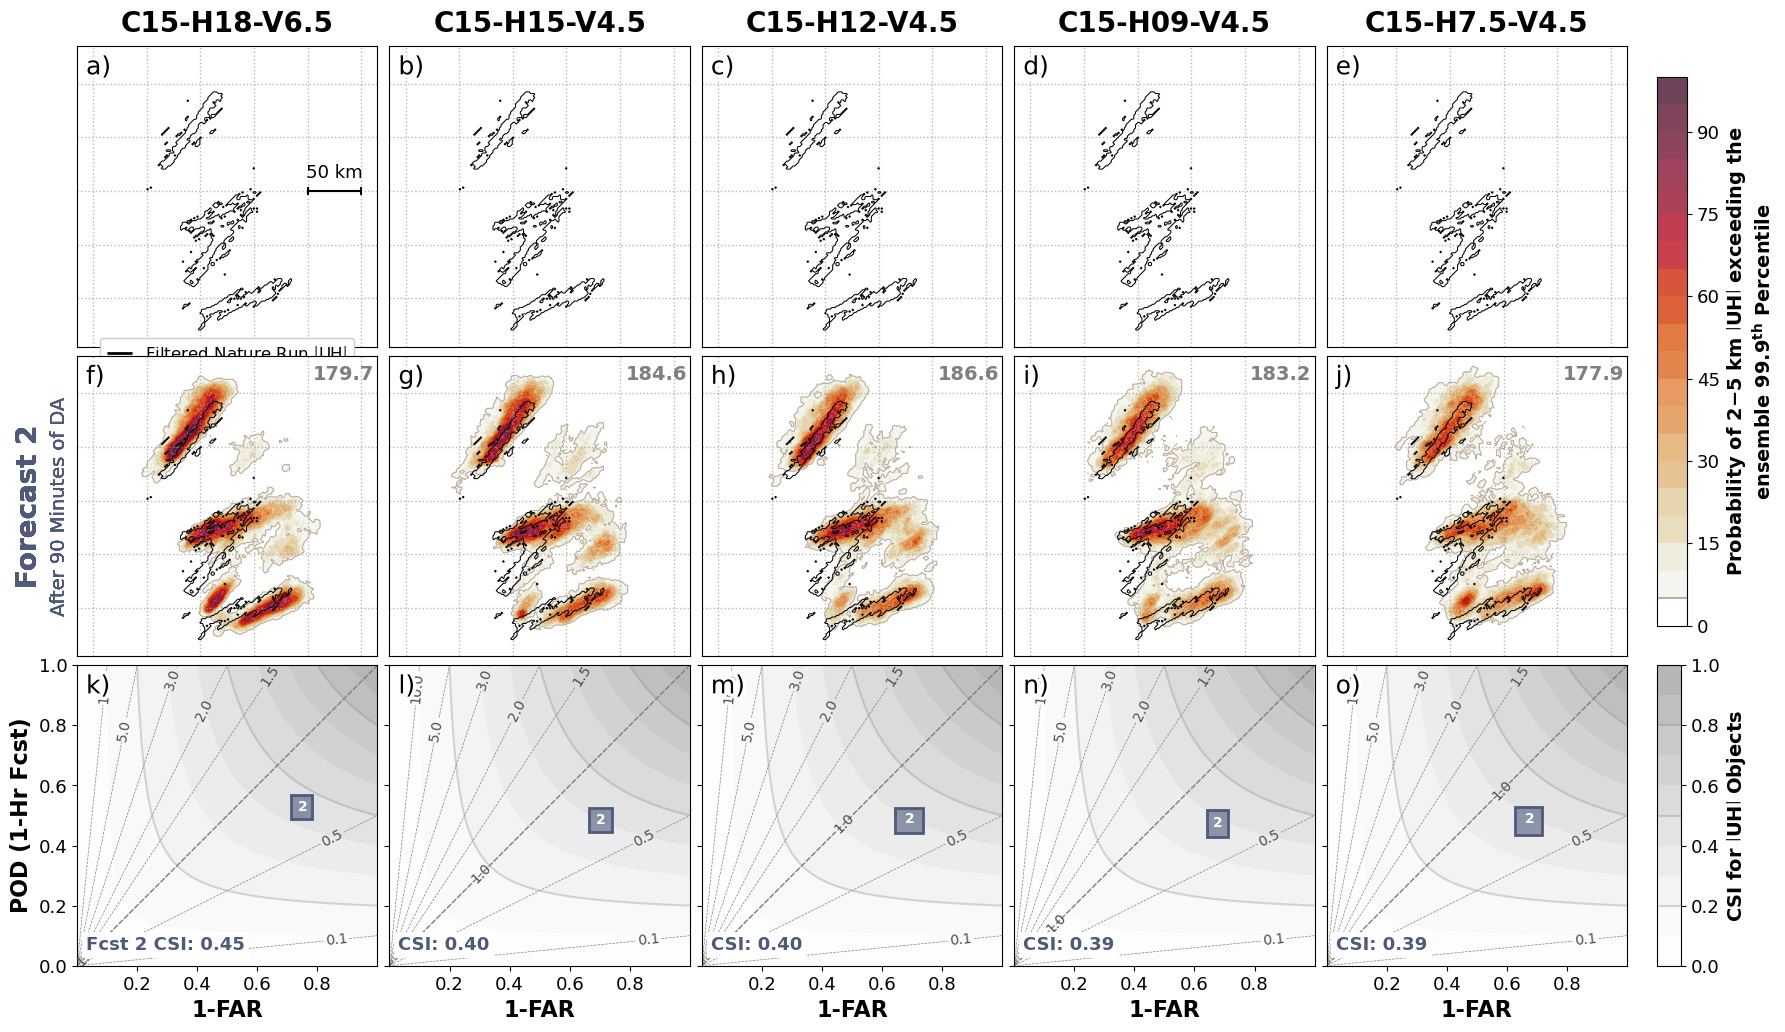

In [58]:


#exps = ['C15_H18_V6','C15_H18_V6_fine','C15_H09_V2','C15_H09_V2_fine']#,'C03_H18_V6','C03_H18_V6_fine','C03_H09_V2','C03_H09_V2_fine']
#exps = ['C15_H18_V6_fine','C15_H09_V2_fine','C03_H18_V6_fine','C03_H09_V2_fine']#
exps = ['C15_H18_V6_fine','C15_H15_V4_fine','C15_H12_V4_fine','C15_H09_V4_fine','C15_H07_V4_fine',]
#exps = ['C03_H12_V4_fine','C03_H09_V4_fine','C03_H07_V4_fine']
version='FULL'

percentile_threshold = 99.9



fig, axes, cbar_width = plot_setup(len(exps))

fcsts = ['FORECAST_20240508_2100', '']
#fcsts = ['']


#### set up the verification swath ####

nr_percentile_vals = {99.75: 69, 99.85: 116, 99.90: 174, 99.95: 289, 99.99: 640}

NR_threshold = nr_percentile_vals[percentile_threshold]
with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc') as NR:
    times_NR = [pd.to_datetime(t) for t in NR.dates.values]
    ti, tf = findnearest(times_NR, dt.datetime(2024,5,8,21,30)),findnearest(times_NR, dt.datetime(2024,5,8,22,30))+1
    NR_UH = abs(NR['UH_2-5km'][ti:tf].values)
    NR_swath = np.clip(np.where(NR_UH >= NR_threshold, 1, 0).sum(axis=0), 0, 1)

    # you can use the xh and yh from the nature run since all experiments are on the same grid
    xh, yh = NR.xh.values, NR.yh.values

#### Make colormaps and set up colors ####
prob_cmap = probability_colormap()
colors = cmaps.lipari(np.linspace(.24,  0.545, len(fcsts)))[::-1]
tlab=['Forecast 1', 'Forecast 2']


for i,exp in enumerate(exps):
    print(i, exp)

    path = f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/"

    axes[0, i].set_title(rename(exp, version=version.upper()), y=1.02, weight='bold', fontsize=20)


    for row, fcst in zip(range(3), fcsts):

        ### read in experiment files and get metadata
        filepath = f"{os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcst)}/full_ens_fcst.nc"
        
        if os.path.exists(filepath):

            ######## now plot swaths - ensemble ########################
            with xr.open_dataset(filepath, decode_timedelta=True) as cm1:
                uh = abs(cm1['UH_2-5km'][-13:,:-1].values)


            # find the ensemble threshold value for the given percentile
            ens_threshold = np.percentile(uh.flatten(), percentile_threshold)
            axes[row, i].text(0.99, 0.97, f"{ens_threshold:.1f}", 
                              transform=axes[row, i].transAxes, ha='right', va='top', fontsize=14, color='k',alpha=0.5,  weight='bold')

            # make proability field
            kernel_1d = get_1d_gaussian_kernel(2.0, truncate=4.0)
            max_3x3 = fast_4d_max_filter_3x3(uh)
            smooth= fast_4d_gaussian_filter(max_3x3, kernel_1d)
            probs = fast_swath_probability(smooth, ens_threshold, 36)
            
            # plot 
            im1=axes[row, i].contourf(xh, yh, probs,  cmap=prob_cmap, levels=np.arange(0, 105, 5), alpha=0.8)
            axes[row, i].contour(     xh, yh, probs,  colors='#bdad9b', levels=[5], linewidths=0.8)

            # Forecast Number (y labels)
            axes[row, 0].text(-0.16, 0.5, tlab[row],                             transform=axes[row, 0].transAxes, rotation=90,ha='center',va='center',fontsize=20,fontweight='bold', color=colors[row])
            axes[row, 0].text(-0.06, 0.5, f'After {60+ row*(30)} Minutes of DA', transform=axes[row, 0].transAxes, rotation=90,ha='center',va='center',fontsize=14, color=colors[row])

        else:
            print(f"no forecast for {exp}, {fcst}")
            
        ######## now plot swaths - nature run ######################
        
        ppath = f"{os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcst)}/performance_UH_p{percentile_threshold}.nc"
        print(ppath)
    
        if os.path.exists(ppath):   

            # ######## wild card - now add performance diagram ###########

            #perf = xr.open_dataset(ppath, decode_timedelta=True)  

            val_dct, ci_dct = generate_CI_contigency(exp,'UH', fcsts=fcst)

            y0 = ci_dct['POD'][0]
            height = ci_dct['POD'][1] - ci_dct['POD'][0]
            
            x0 = ci_dct['SR'][0]
            width = ci_dct['SR'][1] - ci_dct['SR'][0]
            
            rect = patches.Rectangle((x0, y0), width, height, facecolor=np.concatenate((colors[row][0:-1], np.array([0.6]))),edgecolor=np.concatenate((colors[row][0:-1], np.array([1]))), linewidth=2)
            axes[len(fcsts), i].add_patch(rect)

            axes[len(fcsts), i].text(val_dct['SR'][0], val_dct['POD'][0], str(row+1), color='w', ha='center', va='center', weight='bold', zorder=101)

            add=''
            if (i == 0) & (fcst != '') : add = 'Fcst 1 '
            if (i == 0) & (fcst == '') : add = 'Fcst 2 '

            bbox = dict(facecolor='white', alpha=1.0, edgecolor='none', pad=3)

            if fcst != '':
                axes[len(fcsts), i].text(0.03, 0.16+.02, f"{add}CSI: {val_dct['CSI'][0]:.2f}", color=colors[row], ha='left', va='top', weight='bold', zorder=101, fontsize=13,bbox=bbox )
            else:
                axes[len(fcsts), i].text(0.03, 0.08+.02, f"{add}CSI: {val_dct['CSI'][0]:.2f}", color=colors[row], ha='left', va='top', weight='bold', zorder=101, fontsize=13,bbox=bbox )

      


####### performance diagram stuff

for ax in axes[len(fcsts), :]:
    im = performance_diagram(ax, axis_labels=False)
    ax.set_xticks([.2, .4, .6, .8])
    ax.set_xlabel('1-FAR', fontsize=16)

axes[len(fcsts), 0].set_ylabel('POD (1-Hr Fcst)', fontsize=16)

#### probability stuff


for ax in axes[:len(fcsts), :].flatten():
    
    
    imnr=ax.contour(xh, yh, NR_swath, levels=[0.5], colors='k', linewidths=0.75)


    ax.set_yticks(np.arange(50, 400, 50))
    ax.set_xticks(np.arange(50, 400, 50))
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())
    ax.tick_params(axis='both', length=0) 

    buf = 15
    ax.set_xlim(70+buf, 380-buf)
    ax.set_ylim(40+buf, 350-buf)


# need to do this after subplot adjustments 
# UH colorbar
bbox1 = axes[0, len(exps)-1].get_position()  
bbox2 = axes[len(fcsts)-1, len(exps)-1].get_position()  
height = bbox1.y1 - bbox2.y0
cbar_ax1 = fig.add_axes([bbox1.x1+cbar_width, bbox2.y0+height*.05, cbar_width, height*.9])

cbar1 = fig.colorbar(im1, cax=cbar_ax1)
ge = r"$\mathbf{\geq}$"
cbar1.set_label('Probability of '+r'2$\mathbf{-}$5 km $\mathbf{\left| {UH} \right|}$'+' exceeding the\n'+f'ensemble {percentile_threshold}'+r'$\mathbf{^{th}}$ Percentile', weight='bold', fontsize=14)
cbar1.ax.axhline(5,color='#bdad9b' )

# performance diagram colorbar
bbox = axes[len(fcsts), len(exps)-1].get_position()    
cbar_ax = fig.add_axes([bbox.x1+cbar_width,bbox.y0, cbar_width*.8, bbox.y1-bbox.y0])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r'CSI for $\mathbf{\left| {UH} \right|}$ Objects', weight='bold', fontsize=14)
[cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]];

add_scale(axes[0,0], xstart=300,y=200, text_bump=5)


for i,ax in enumerate(axes.flatten()):
    ax.text(0.03, 0.97,  chr(ord('`')+i+1)+')', va='top', fontsize=18, transform=ax.transAxes, path_effects=[path_effects.Stroke(linewidth=5, foreground='white'),
                           path_effects.Normal()], zorder=500)

h, _ = imnr.legend_elements()
l = [r'Filtered Nature Run $\left| \mathrm{UH} \right|$']
leg=axes[0,0].legend(h, l, loc='lower center', fontsize=12, handlelength=1.5, bbox_to_anchor=(0.5,-0.1))
for line in leg.get_lines():
    line.set_linewidth(2.0)

# axes[0,-1].text(160-10, 230, 'L1', weight='bold', color='0.6', fontsize=15, ha='right', va='top')
# axes[0,-1].text(180-10, 175, 'R1', weight='bold', color='0.6', fontsize=15, ha='right', va='top')
# axes[0,-1].text(185, 130,    'L2', weight='bold', color='0.6', fontsize=15, ha='right', va='top')
# axes[0,-1].text(200, 90,     'R2', weight='bold', color='0.6', fontsize=15, ha='right', va='top')


0 C03_H18_V4
1 C03_H15_V4
2 C03_H12_V4
3 C03_H09_V4
4 C03_H07_V4


Text(190, 90, 'R2')

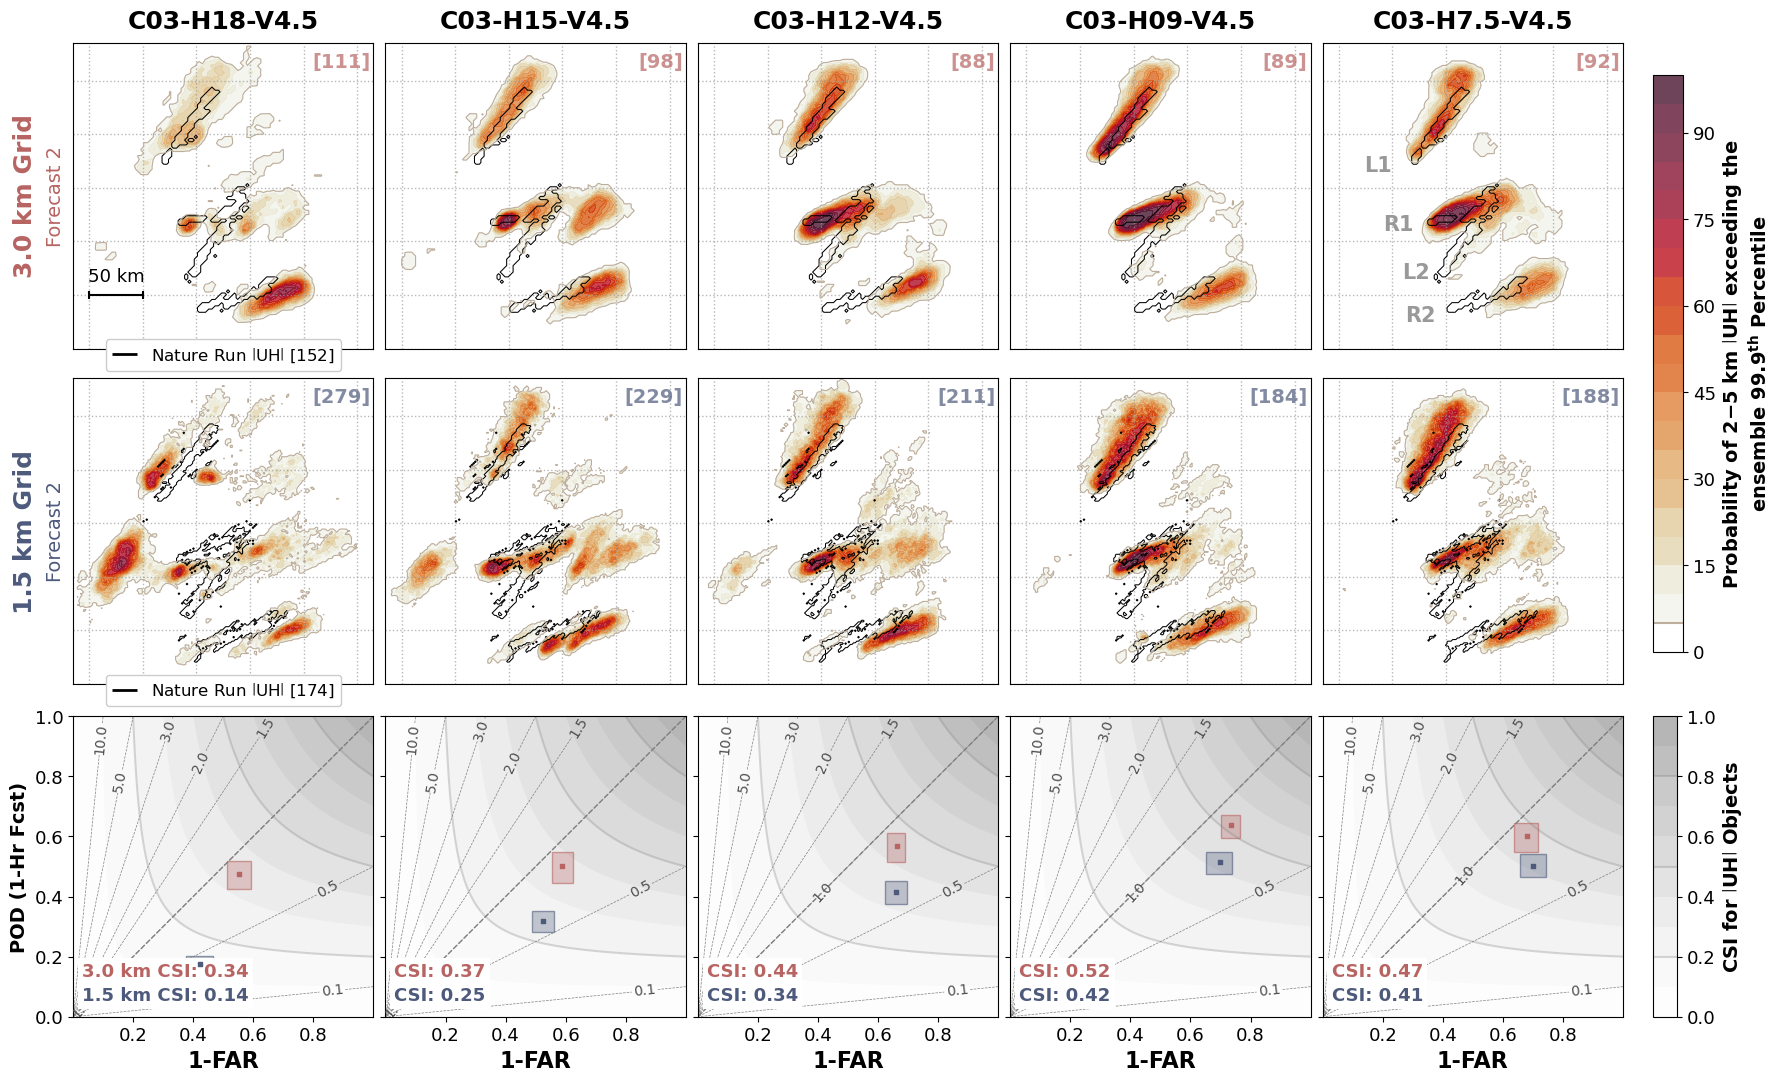

In [10]:


var = 'cdbz'
percentile_threshold = 99.5 #98

var = 'UH'
percentile_threshold = 99.9

exps = ['C15_H15_V4','C15_H12_V4','C15_H09_V4','C15_H07_V4',]
exps = ['C03_H18_V4','C03_H15_V4','C03_H12_V4','C03_H09_V4','C03_H07_V4',]
#exps = ['C03_H12_V4','C03_H09_V4','C03_H09_V2','C03_H07_V4',]

#exps = ['C15_H15_V6','C15_H15_V4','C15_H15_V2']
#exps = ['C03_H09_V6','C03_H09_V4','C03_H09_V2']
fcst = '' # you can only do 1 forecast time step for this plot
version='FULL'



##########################################################################################
nr_percentile_vals = {
  '3km' : {'UH':{99.75: 53, 99.85: 96,  99.90: 152, 99.95: 256, 99.99: 493}, 'cdbz':{95.0: 23, 97.0: 33, 98.0: 40, 99.0: 47, 99.5: 53}}, 
 '1.5km': {'UH':{99.75: 69, 99.85: 116, 99.90: 174, 99.95: 289, 99.99: 640}, 'cdbz':{95.0: 22, 97.0: 34, 98.0: 40, 99.0: 48, 99.5: 53}}}


fig, axes, cbar_width = plot_setup(len(exps))


# set everything for the variable type 
if var == 'UH': 
    varname = 'UH_2-5km'
    prob_label = 'Probability of '+r'2$\mathbf{-}$5 km $\mathbf{\left| {UH} \right|}$'+' exceeding the\n'+f'ensemble {percentile_threshold}'+r'$\mathbf{^{th}}$ Percentile'
    perf_label = r'CSI for $\mathbf{\left| {UH} \right|}$ Objects'
    leg_label = r'Nature Run $\left| \mathrm{UH} \right|$'

else: 
    varname = 'cdbz'
    prob_label = 'Probability of CRef'+' exceeding the\n'+f'ensemble {percentile_threshold}'+r'$\mathbf{^{th}}$ Percentile'
    perf_label = r'CSI for CRef Objects'
    leg_label = r'Nature Run CRef'

#### Make colormaps and set up colors ####
prob_cmap = probability_colormap()
colors = cmaps.lipari(np.linspace(.24,  0.545, 2))[::-1]

#################################################################################################################################
### read in both of the nature run files 
with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars_fine.nc') as NR:
    NR_UH = abs(NR[varname][110:171].values)
    NR_swath_fine = np.clip(np.where(NR_UH >= nr_percentile_vals['1.5km'][var][percentile_threshold], 1, 0).sum(axis=0), 0, 1)
    xf, yf = NR.xh.values, NR.yh.values

with xr.open_dataset('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars.nc') as NR:
    NR_UH = abs(NR[varname][110:171].values)
    NR_swath = np.clip(np.where(NR_UH >= nr_percentile_vals['3km'][var][percentile_threshold], 1, 0).sum(axis=0), 0, 1)
    xh, yh = NR.xh.values, NR.yh.values

### add in nature run
for ax in axes[0,:]: imnr=ax.contour(xh, yh, NR_swath, levels=[0.5], colors='k', linewidths=0.75)
for ax in axes[1,:]: imnr=ax.contour(xf, yf, NR_swath_fine, levels=[0.5], colors='k', linewidths=0.75)

# the legend for the nature run 
for i, grid in enumerate(['3km', '1.5km']):
    h, _ = imnr.legend_elements()
    l = [leg_label + f" [{nr_percentile_vals[grid][var][percentile_threshold]}]"]
    
    leg=axes[i,0].legend(h, l, loc='lower center', fontsize=12, handlelength=1.5, bbox_to_anchor=(0.5,-0.1))
    for line in leg.get_lines():
        line.set_linewidth(2.0)

#################################################################################################################################

#################################################################################################################################
### now loop over the experiments
for i,exp in enumerate(exps):
    print(i, exp)

    path  = f"{os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp, fcst)}/full_ens_fcst.nc"
    pathf = f"{os.path.join('/work/jessica.mcdonald/CM1_LETKF_2025/experiments/',exp+'_fine', fcst)}/full_ens_fcst.nc"

    axes[0, i].set_title(rename(exp, version=version.upper()), y=1.02, weight='bold', fontsize=18)

    #if os.path.exists(filepath):

    ####### now plot swaths - ensemble ########################
    with xr.open_dataset(path, decode_timedelta=True) as cm1:
        myvar = abs(cm1[varname][-13:,:-1].values)
        ens_threshold = np.percentile(myvar.flatten(), percentile_threshold)
        probs = get_probability_swath(myvar, ens_threshold)
    
        im1=axes[0, i].contourf(xh, yh, probs,  cmap=prob_cmap, levels=np.arange(0, 105, 5), alpha=0.8)
        axes[0, i].contour(     xh, yh, probs,  colors='#bdad9b', levels=[5], linewidths=0.8)

    with xr.open_dataset(pathf, decode_timedelta=True) as cm1:
        myvar = abs(cm1[varname][-13:,:-1].values)
        ens_thresholdf = np.percentile(myvar.flatten(), percentile_threshold)
        probsf = get_probability_swath(myvar, ens_thresholdf)
     
        im1=axes[1, i].contourf(xf, yf, probsf,  cmap=prob_cmap, levels=np.arange(0, 105, 5), alpha=0.8)
        axes[1, i].contour(     xf, yf, probsf,  colors='#bdad9b', levels=[5], linewidths=0.8)


    # add in what the percentile value is for the ensemble
    for row, thresh in enumerate([ens_threshold, ens_thresholdf]):
        axes[row, i].text(0.99, 0.97, f"[{thresh:.0f}]", transform=axes[row, i].transAxes, ha='right', va='top', fontsize=14, color=colors[row],alpha=0.7,  weight='bold')

    # add in the performance diagram 
    add_CI_boxes(exp,        var, percentile_threshold, fcst, axes[2, i], colors[0], texty=.18, add = '3.0 km ' if i == 0 else '')
    add_CI_boxes(exp+'_fine', var, percentile_threshold, fcst, axes[2, i], colors[1], texty=.1,  add = '1.5 km ' if i == 0 else '')

#################################################################################################################################

#### y labels for the grid sizes 
fcast = 'Forecast 1'
if fcst == '': fcast = 'Forecast 2'

for row, label in enumerate(['3.0 km Grid', '1.5 km Grid']):
    axes[row, 0].text(-0.16, 0.5, label, transform=axes[row, 0].transAxes, rotation=90,ha='center',va='center',fontsize=18,fontweight='bold', color=colors[row])
    axes[row, 0].text(-0.06, 0.5, fcast, transform=axes[row, 0].transAxes, rotation=90,ha='center',va='center',fontsize=14, color=colors[row])


### set up performance diagram 
axes[2, 0].set_ylabel('POD (1-Hr Fcst)', fontsize=14)
for ax in axes[2, :]:
    im = performance_diagram(ax, axis_labels=False)
    ax.set_xticks([.2, .4, .6, .8])
    ax.set_xlabel('1-FAR', fontsize=16)

### plot formatting 
for ax in axes[:2, :].flatten():
    ax.set_yticks(np.arange(50, 400, 50))
    ax.set_xticks(np.arange(50, 400, 50))
    ax.grid(ls=':', alpha=0.7)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())
    ax.tick_params(axis='both', length=0) 
    ax.set_xlim(85, 365)
    ax.set_ylim(50, 335)

# Probability colorbar 
bbox1 = axes[0, len(exps)-1].get_position()  
bbox2 = axes[1, len(exps)-1].get_position()  
height = bbox1.y1 - bbox2.y0
cbar_ax1 = fig.add_axes([bbox1.x1+cbar_width, bbox2.y0+height*.05, cbar_width, height*.9])
cbar1 = fig.colorbar(im1, cax=cbar_ax1)
cbar1.set_label(prob_label, weight='bold', fontsize=14)
cbar1.ax.axhline(5,color='#bdad9b' )

# performance diagram colorbar
bbox = axes[2, len(exps)-1].get_position()    
cbar_ax = fig.add_axes([bbox.x1+cbar_width,bbox.y0, cbar_width*.8, bbox.y1-bbox.y0])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(perf_label, weight='bold', fontsize=14)
[cbar.ax.axhline(l, color='0.5', alpha=0.3)  for l in [0.2, 0.5, 0.8]];

add_scale(axes[0,0], xstart=100,y=100, text_bump=5)

# if you want to add in numbers
# for i,ax in enumerate(axes.flatten()): add_subplot_labels(ax, i, x=0.03, y=0.97)

axes[0,-1].text(160-10, 230, 'L1', weight='bold', color='0.6', fontsize=15, ha='right', va='top')
axes[0,-1].text(180-10, 175, 'R1', weight='bold', color='0.6', fontsize=15, ha='right', va='top')
axes[0,-1].text(185, 130,    'L2', weight='bold', color='0.6', fontsize=15, ha='right', va='top')
axes[0,-1].text(190, 90,     'R2', weight='bold', color='0.6', fontsize=15, ha='right', va='top')

# Object Tracking Validation

In [11]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial import distance_matrix

def force_eval(string):
    if type(string) == str:

        if '...' not in string:
            try:
                ret=np.array(eval(string.replace(' ', ',').replace('[,', '[').replace('\n', ',').replace(',,', ',')))
            except:
                ret =np.array(eval(string.replace('. ', '. ,').replace('\n', ',')))
            return ret
        else:
            print(' the ellipses bug happened...')
    else:
        print(f'TypeError: this function only processes a string and you gave type {type(string)}')

def track_objects_hungarian(
    df, frame_col, coord_cols, max_distance=float("inf")
):
    """Tracks objects across multiple frames using sequential Hungarian matching.

    Parameters:
    - df: pandas DataFrame
    - frame_col: string, name of the frame/time column
    - coord_cols: list of strings, features to match on (e.g., ['x', 'y'])
    - max_distance: float, max allowed movement distance between frames
    """
    # 1. Sort by frame and initialize the tracking ID column
    df = df.sort_values(by=frame_col).copy()
    df["track_id"] = -1

    frames = sorted(df[frame_col].unique())
    if not frames:
        return df

    # 2. Initialize IDs for the very first frame
    first_frame_mask = df[frame_col] == frames[0]
    num_initial_objects = first_frame_mask.sum()
    df.loc[first_frame_mask, "track_id"] = range(num_initial_objects)
    next_id = num_initial_objects

    # Keep track of the previous frame's rows
    prev_frame_df = df[first_frame_mask]

    # 3. Loop sequentially through the remaining frames
    for t in frames[1:]:
        curr_frame_df = df[df[frame_col] == t]

        if curr_frame_df.empty:
            continue
        if prev_frame_df.empty:
            # If the previous frame was completely empty, treat all current as new
            df.loc[curr_frame_df.index, "track_id"] = range(
                next_id, next_id + len(curr_frame_df)
            )
            next_id += len(curr_frame_df)
            prev_frame_df = df[df[frame_col] == t]
            continue

        # Extract coordinates for matching
        prev_coords = prev_frame_df[coord_cols].values
        curr_coords = curr_frame_df[coord_cols].values

        # Compute fast vectorized distance matrix
        cost_matrix = distance_matrix(prev_coords, curr_coords)

        # Apply Hungarian Algorithm
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        assigned_curr_indices = set()

        # Map IDs based on optimal assignment
        for r, c in zip(row_ind, col_ind):
            # Gating step: only link if they are close enough
            if cost_matrix[r, c] <= max_distance:
                prev_idx = prev_frame_df.index[r]
                curr_idx = curr_frame_df.index[c]

                # Pass the track_id forward
                df.at[curr_idx, "track_id"] = df.at[prev_idx, "track_id"]
                assigned_curr_indices.add(c)

        # Handle unassigned objects in the current frame (spawn new tracks)
        for c in range(len(curr_coords)):
            if c not in assigned_curr_indices:
                curr_idx = curr_frame_df.index[c]
                df.at[curr_idx, "track_id"] = next_id
                next_id += 1

        # Advance to the next step
        prev_frame_df = df[df[frame_col] == t]

    return df


def plot_tracks(ax, exp, name, p_threshold):

    all_mem   = pd.read_csv(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/objects_{name}_p{p_threshold}.csv')
    verif_obj = pd.read_csv(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/verification_{name}_p{p_threshold}.csv')
    all_mem['time']   = pd.to_datetime(all_mem['time'])
    verif_obj['time'] = pd.to_datetime(verif_obj['time'])

    for m in range(0, 36):
        mem = all_mem[all_mem.member == m+1].copy()
        mem_tracked = track_objects_hungarian(mem, frame_col='time', coord_cols=['X0', 'Y0'], max_distance=10)
        for track in mem_tracked.track_id.unique():
            track_mask = mem_tracked[mem_tracked.track_id == track]
            ax.plot(track_mask.X0, track_mask.Y0, alpha=0.3, color='k', lw=0.5)

    nomatch = all_mem[all_mem.closest == 0].copy()
    ax.scatter(nomatch.X0, nomatch.Y0, color='k', alpha=0.1, s=5, label='Unmatched Ensemble Objects')

    vtrack = track_objects_hungarian(verif_obj, frame_col='time', coord_cols=['X0', 'Y0'], max_distance=20)     
    unique_tracks = vtrack['track_id'].unique()

    colors = cmaps.pride(np.linspace(.2, .8, 12))
    colors = [colors[i] for i in [11,0,5,3,9,6,2,10,7,4,1,8]]

    for track_id, color in zip(unique_tracks, colors):
        track_data = vtrack[vtrack['track_id'] == track_id]
        

        for obj_id in track_data['Object_ID']:
            obj_data = all_mem[all_mem['closest'] == obj_id]
            ax.scatter(obj_data['X0'], obj_data['Y0'], color=color, s=5, zorder=100, alpha=0.5, label='Matched Ensemble Objects')

        ax.plot(track_data['X0'], track_data['Y0'], marker='s',mec='k', label=f'Verification Objects', color=color, zorder=500)
        

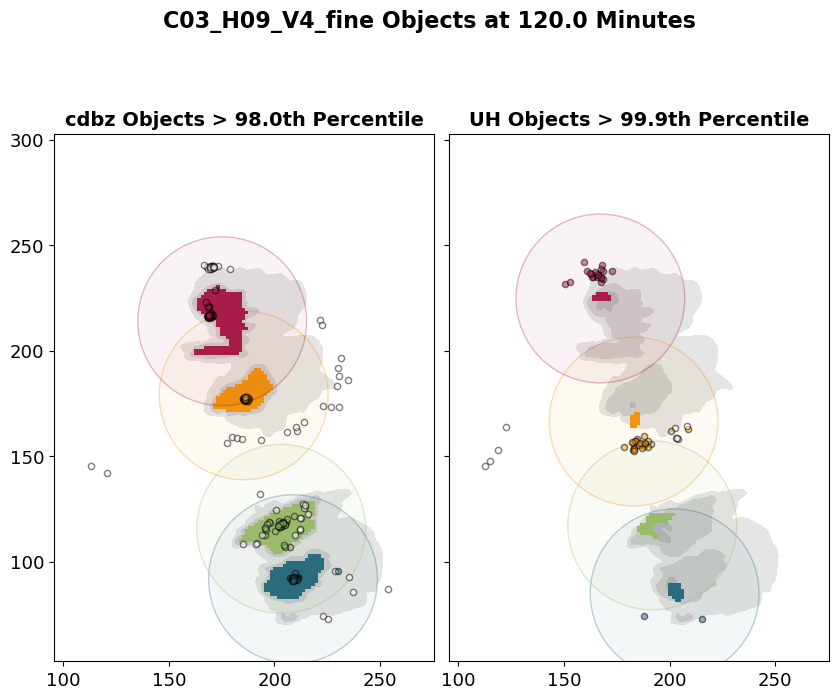

In [138]:
#######################################################
# set exp
exp = 'C03_H09_V4_fine'

# set time (0 thru 11)
t=0

# set variable and percentile threshold for object identification
names = ['cdbz', 'UH']
p_thresholds = [98.0, 99.9]


#######################################################
#######################################################

fig, axes =plt.subplots(1,2,figsize=(10,8), sharex=True, sharey=True, subplot_kw={'aspect':'equal'})

add = ''
if 'fine'  in exp: add='_fine'

ds = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/Processed_VerificationVars{add}.nc') 
ds = ds.isel(t = slice(110,171, 5))
times_NR = [pd.to_datetime(t) for t in ds.dates.values]
xh, yh = np.meshgrid(ds.xh, ds.yh)

time_min = (times_NR[t] - dt.datetime(2024,5,8,19,30)).seconds/60

fig.suptitle(f'{exp} Objects at {time_min} Minutes', fontsize=16, weight='bold')

for ax in axes:
    ax.contourf(xh, yh, ds['cdbz'].values[t],levels=[20,100], colors='k', alpha=0.1)
    ax.contourf(xh, yh, ds['cdbz'].values[t],levels=[40,100], colors='k', alpha=0.1)
    ax.contourf(xh, yh, ds['cdbz'].values[t],levels=[60,100], colors='k', alpha=0.1)
    # ax.set_xlim(170-20,320)
    # ax.set_ylim(70,300)
  
################# reflectivity objects

for ax, name, p_threshold in zip(axes, names, p_thresholds):

    all_mem   = pd.read_csv(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/objects_{name}_p{p_threshold}.csv')
    verif_obj = pd.read_csv(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/verification_{name}_p{p_threshold}.csv')
    all_mem['time']   = pd.to_datetime(all_mem['time'])
    verif_obj['time'] = pd.to_datetime(verif_obj['time'])

    vob = verif_obj[verif_obj.time == times_NR[t]]
    mem = all_mem[all_mem.time == times_NR[t]]


    colors = cmaps.pride(np.linspace(.2, .8, len(vob.index)))

    for v,vi in enumerate(vob.index):
        mask = np.zeros_like(xh)*np.nan
        coords = force_eval(vob.coords[vi])
        for c in coords:
            mask[c[0],c[1]] = 1
        ax.pcolormesh(xh, yh, mask, alpha=1, cmap=mpl.colors.ListedColormap([colors[v]]))

        rx,ry = vob.loc[vi]['X0'], vob.loc[vi]['Y0']
        ax.add_patch(plt.Circle((rx,ry), 40, fill=True,facecolor=np.concatenate((colors[v][0:-1], np.array([0.05]))),
                                 edgecolor=np.concatenate((colors[v][0:-1], np.array([0.3])))))
        
    for m in mem.index:

        if mem.loc[m]['closest'] == 0: color='w'
            #alpha=1
        else: color = colors[findnearest(vob.Object_ID, mem.loc[m]['closest'])]
            #alpha=1
        alpha=0.5
        ax.scatter(mem.loc[m].X0, mem.loc[m].Y0, color=color, alpha=alpha, s=20, ec='k')

    ax.set_title(f"{name} Objects > {p_threshold}th Percentile", fontsize=14, weight='bold')

    cx, cy = np.mean(mem.X0.values), np.mean(mem.Y0.values)
    ax.set_xlim(cx-80, cx+100)
    ax.set_ylim(cy-130, cy+120)

plt.subplots_adjust(wspace=0.04)

ds.close()

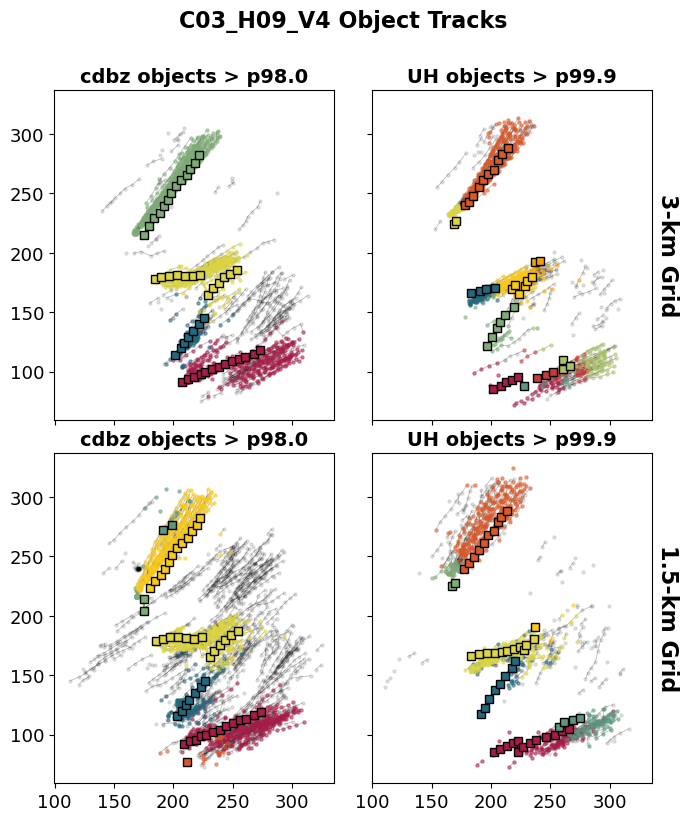

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8,9), sharex=True, sharey=True, subplot_kw={"aspect": "equal"})

names = ['cdbz', 'UH']
p_thresholds = [98.0, 99.9]

exp = 'C03_H09_V4'
for name, p_threshold, ax in zip(names, p_thresholds, axes[0,:]):
    plot_tracks(ax, exp, name, p_threshold)
    ax.set_title(f'{name} objects > p{p_threshold}', fontsize=14)

for name, p_threshold, ax in zip(names, p_thresholds, axes[1,:]):
    plot_tracks(ax, exp+'_fine', name, p_threshold)
    ax.set_title(f'{name} objects > p{p_threshold}', fontsize=14)

plt.subplots_adjust(wspace=0.05, hspace=0.1)
plt.suptitle(f'{exp} Object Tracks', fontsize=16, weight='bold', y=.97)

xt, yt = centered_on_axes(axes, 0, version='on')
fig.text(xt+.02, yt, '3-km Grid', ha='center', va='center', rotation=-90, weight='bold', fontsize=16);
xt, yt = centered_on_axes(axes, 1, version='on')
fig.text(xt+.02, yt, '1.5-km Grid', ha='center', va='center', rotation=-90, weight='bold', fontsize=16);

(-10.0, 500.0)

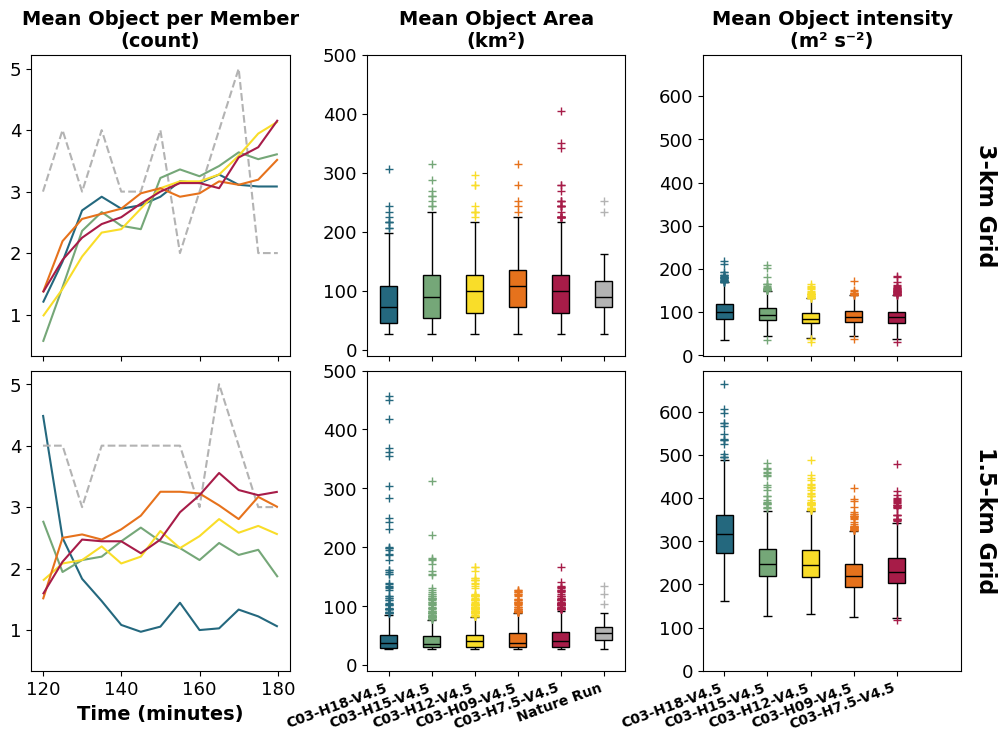

In [18]:


def object_count_plot(axes, exp, n_exp, ei, color):

    all_mem   = pd.read_csv(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/objects_{name}_p{p_threshold}.csv')
    all_mem['time_min'] = (pd.to_datetime(all_mem.time) - dt.datetime(2024,5,8,19,30)).dt.total_seconds()/60

  
    ### counts
    n_member = len(np.unique(all_mem['member']))
    counts    = all_mem['time_min'].value_counts().sort_index()
    axes[0].plot(counts.index, counts.values/n_member, label=rename(exp, version=version), color=color)
    

    ### object_size box plots

    area    = all_mem['area'].values
    buf = .4
    bp  = axes[1].boxplot(area,    positions = [ei],    widths = buf, patch_artist=True, flierprops={'marker':'+'})
    

    for item in ['boxes', 'whiskers', 'medians', 'caps']:
        plt.setp(bp[item], color='k')
    for b,(box,fly) in enumerate(zip(bp['boxes'],bp['fliers'])):
        box.set(facecolor=color)
        fly.set_markeredgecolor(color)
    
    ### object intensity box plots
    intensity    = all_mem['intensity_mean'].values
    bp = axes[2].boxplot(intensity, positions = [ei], widths = buf, patch_artist=True, flierprops={'marker':'+'})

    for item in ['boxes', 'whiskers', 'medians', 'caps']:
        plt.setp(bp[item], color='k')
    for b,(box,fly) in enumerate(zip(bp['boxes'],bp['fliers'])):
        box.set(facecolor=color)
        fly.set_markeredgecolor(color)


    if ei == 0:

        verif_obj = pd.read_csv(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/verification_{name}_p{p_threshold}.csv')
        verif_obj['time_min'] = (pd.to_datetime(verif_obj.time) - dt.datetime(2024,5,8,19,30)).dt.total_seconds()/60

        counts_NR = verif_obj['time_min'].value_counts().sort_index()
        area_NR   = verif_obj['area'].values

        axes[0].plot(counts_NR.index, counts_NR.values, color='0.7', ls='--', label=r'Verification')
        bp1 = axes[1].boxplot(area_NR, positions = [n_exp], widths = buf, patch_artist=True, flierprops={'marker':'+'})
        for item in ['boxes', 'whiskers', 'medians', 'caps']:
            plt.setp(bp1[item], color='k')

        for b,(box,fly) in enumerate(zip(bp1['boxes'],bp1['fliers'])):
            box.set(facecolor='0.7')
            fly.set_markeredgecolor('0.7')



exps = ['C15_H15_V6','C15_H15_V4','C15_H15_V2']#, 'C03_H09_V4', 'C03_H09_V2', 'C03_H07_V4']
exps = ['C15_H18_V4', 'C15_H15_V4', 'C15_H12_V4', 'C15_H09_V4', 'C15_H07_V4']
exps = ['C03_H18_V4', 'C03_H15_V4', 'C03_H12_V4', 'C03_H09_V4', 'C03_H07_V4']

# name = 'cdbz'
# p_threshold = 99.5

name = 'UH'
p_threshold = 99.9

version='FULL'

fig, axes = plt.subplots(2, 3, figsize=(12,8), sharex='col', sharey='col')
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))
if len(exps)==3: colors = list(cmaps.pride([.2, .75, .6]))


for ei, exp in enumerate(exps):
    
    n_exp    = len(exps)
    color = colors[ei]


    object_count_plot(axes[0,:], exp, n_exp, ei, color)

    object_count_plot(axes[1,:], exp+'_fine', n_exp, ei, color)


for ax in axes[1:,1:].flatten():ax.set_xlim(-0.5, len(exps)+0.5)

plt.subplots_adjust(wspace=.3, hspace=0.05)

if name == 'UH': units = 'm² s⁻²'
else: units = 'dBZ'

#axes[0,0].legend(loc='upper center', fontsize=10, handlelength=0.5, ncol=2)

axes[0,0].set_title('Mean Object per Member\n(count)', fontsize=14)
axes[0,1].set_title('Mean Object Area\n(km²)', fontsize=14)
axes[0,2].set_title(f'Mean Object intensity\n({units})', fontsize=14)

axes[1,0].set_xlabel('Time (minutes)', fontsize=14)

axes[1,1].set_xticks(range(len(exps)+1), labels=[rename(e, version=version) for e in exps]+['Nature Run'],
                      rotation=20, weight='bold', fontsize=10, ha='right')
axes[1,2].set_xticks(range(len(exps)), labels=[rename(e, version=version) for e in exps],
                      rotation=20, weight='bold', fontsize=10,ha='right')

xt, yt = centered_on_axes(axes, 0, version='on')
fig.text(xt+.02, yt, '3-km Grid', ha='center', va='center', rotation=-90, weight='bold', fontsize=16);
xt, yt = centered_on_axes(axes, 1, version='on')
fig.text(xt+.02, yt, '1.5-km Grid', ha='center', va='center', rotation=-90, weight='bold', fontsize=16);

axes[1,1].set_ylim(-10, 500)

# FSS bar charts

no file for C03_H15_V6_fine/
no file for C03_H15_V6_fine/
no file for C03_H12_V6_fine/
no file for C03_H12_V6_fine/
no file for C03_H07_V6_fine/
no file for C03_H07_V6_fine/
no file for C03_H18_V2_fine/
no file for C03_H18_V2_fine/
no file for C03_H15_V2_fine/
no file for C03_H15_V2_fine/


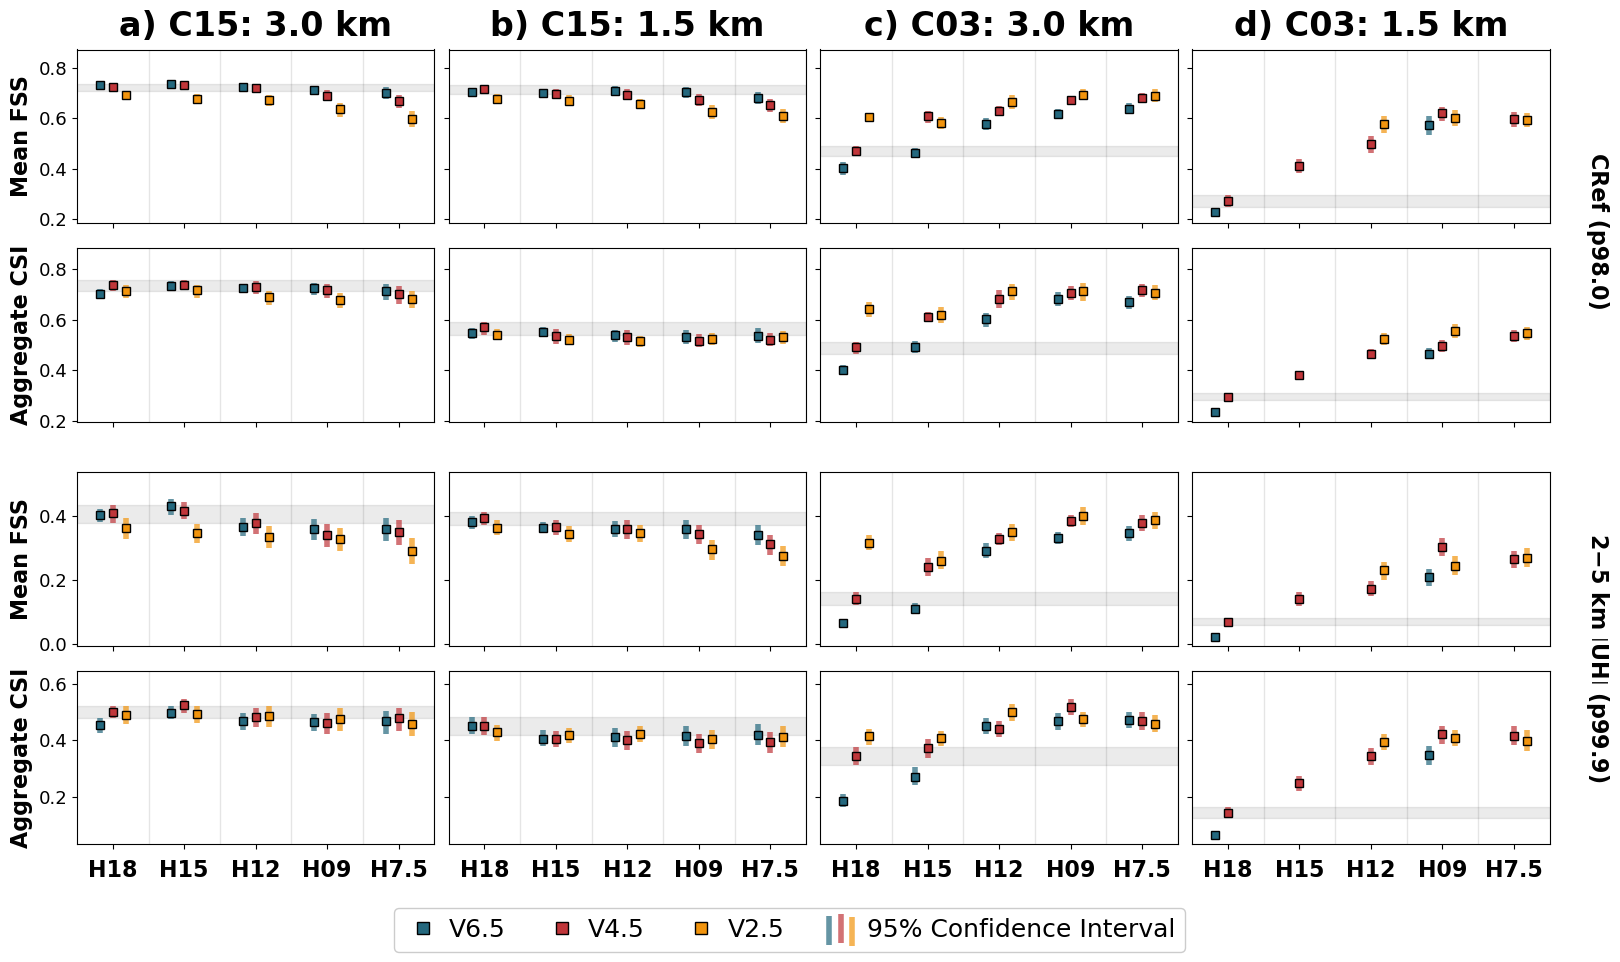

In [2]:

hloc = [18, 15, 12, 9, 7]
vloc = [6,4,2]

freq=[15,15, 3, 3]
#freq=[3]
fcsts = ['']
#fcsts = ['FORECAST_20240508_2100']
#fcsts = ['FORECAST_20240508_2100', '']


## eFSS stuff
myvars = ['cdbz', 'UH']
mythres  = [98.0, 99.9]
neighborhood_size = 24 # km 


#################################################################
if len (freq) == 3:
    fig, axes = plt.subplots(4,3, figsize=(14, 10), sharey='row', sharex=True)
else:
    fig, axes = plt.subplots(4,4, figsize=(19, 10), sharey='row', sharex=True)


hloc_i = range(len(hloc))
vloc_i = range(len(vloc))
gridx, gridy = np.meshgrid(hloc_i, vloc_i)
colors = list(cmaps.pride([.2, .75, .6]))


ls     = '-'
lw     = 3
alpha  = 0.8
#marker = 's'
ms     = 6


if len(fcsts)>1: fcst_diff=True
else: fcst_diff=False

COUNT = 0

for ci, c in enumerate(freq):

    temp_table  = np.zeros([4,    len(hloc), len(vloc)])*np.nan
    stat_table  = np.zeros([4,    len(hloc), len(vloc)])*np.nan
    ci_table    = np.zeros([4, 2, len(hloc), len(vloc)])*np.nan # second index is for lower and upper bound

    for vi, v in enumerate(vloc):
        for hi, h in enumerate(hloc):
            for i,var in enumerate(myvars):

                try:

                    if (COUNT == 0)| (COUNT == 2):
                        exp =  f"C{c:02d}_H{h:02d}_V{v}/"
                    else:
                        exp =  f"C{c:02d}_H{h:02d}_V{v}_fine/"

                    # i should be (i*2) + 1

                    axes[i*2, 0].set_ylabel(f'Mean FSS', fontsize=16)
                    axes[(i*2)+1, 0].set_ylabel(f'Aggregate CSI', fontsize=16)

                    val_dct, ci_dct = generate_CI_contigency(exp, var, fcsts=fcsts, fcst_diff=fcst_diff)
                
                    if fcst_diff:
                        fss_vals, ci_val1, ci_val2, stat = generate_CI_FSS(exp, var, neighborhood=24, thresh=mythres[i], fcsts=fcsts, fcst_diff=fcst_diff)
                        stat_table[i*2, hi, vi] = stat

                        stat_table[(i*2)+1, hi, vi] = ci_dct['CSI_sig']

                    else:
                        fss_vals, ci_val1, ci_val2 = generate_CI_FSS(exp, var, neighborhood=24, thresh=mythres[i], fcsts=fcsts, fcst_diff=fcst_diff)
                        

                    temp_table[i*2, hi, vi]   = fss_vals
                    ci_table[i*2,0, hi, vi]   =  ci_val1
                    ci_table[i*2,1, hi, vi]   =  ci_val2


                    temp_table[(i*2)+1, hi, vi]   =  val_dct['CSI'][0]
                    ci_table[(i*2)+1,0, hi, vi]   =  ci_dct['CSI'][0]
                    ci_table[(i*2)+1,1, hi, vi]   =  ci_dct['CSI'][1]
        
              
                except: print(f'no file for {exp}')
    for i in range(4):

        shift = .18
        for vi, v in enumerate(vloc):
            name = rename(f'C03_H09_V{v}', version='V').split('-')[1]
    
            xoff = shift * (vi - 1)
            axes[i, ci].errorbar(np.array(hloc_i)+xoff, temp_table[i,:,vi], yerr=abs(ci_table[i,:,:,vi]-temp_table[i,:,vi]), marker='s', ms=0,mec='k', lw=0,color=colors[vi], elinewidth=4,capsize=0, label=name, alpha=0.7)
            axes[i, ci].plot(np.array(hloc_i)+xoff, temp_table[i,:,vi], color=colors[vi], ls=ls, marker='s',markersize=ms,markeredgecolor='k', linewidth=0, alpha=1, label=name)

            if v == 4:
                conh = findnearest(hloc, 18)
                axes[i, ci].axhspan(ci_table[i,0, conh,vi],ci_table[i,1, conh,vi], alpha=0.08, color='k')#colors[vi])


            # now loop over 
            if fcst_diff:
                for hi, h in enumerate(hloc):

                    if stat_table[i, hi, vi] == -1:     
                        axes[i, ci].plot(hi+xoff, .92, marker = 'v', markeredgecolor=colors[vi], markerfacecolor=colors[vi], lw=0, markersize=7, transform = transforms.blended_transform_factory(axes[i, ci].transData,axes[i, ci].transAxes))
                    if stat_table[i, hi, vi] == 1:
                        axes[i, ci].plot(hi+xoff, .92, marker = '^', markeredgecolor=colors[vi], markerfacecolor=colors[vi], lw=0, markersize=7, transform = transforms.blended_transform_factory(axes[i, ci].transData,axes[i, ci].transAxes))
                    if stat_table[i, hi, vi] == 999:
                        axes[i, ci].plot(hi+xoff, .92, marker = 'x', markeredgecolor=colors[vi], markerfacecolor=colors[vi], lw=0, markersize=7, transform = transforms.blended_transform_factory(axes[i, ci].transData,axes[i, ci].transAxes))
           
    COUNT += 1

for ax in axes.flatten():
    ax.set_xticks(hloc_i,[rename(f'C03_H{m:02d}_V4', version='H').split('-')[1] for m in hloc], weight='bold', fontsize=16)#, pad=10)
    ax.set_xlim(-0.5, len(hloc)-0.5)
    _=[ax.axvline(hl+.5, color='k', alpha=0.1, lw=1) for hl in hloc_i]
    ax.tick_params(axis='x', which='major', pad=7)

    y0,y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 + 0.03*y1)
    # ax.set_ylim(0,1)


# set titles
for ci,c in enumerate(freq):   
    if ci%2 == 0: grid = ': 3.0 km' 
    else: grid = ': 1.5 km'

    axes[0, ci].set_title(chr(ord('`')+ci+1)+') '+rename(f'C{c:02d}_H09_V4', version='CI')+grid, weight='bold', fontsize=24,  y=1.03)

plt.subplots_adjust(hspace=0.15, wspace=0.04)


### add space betweent he plots
for ax in axes[0:2,:].flatten():
    pos = ax.get_position()
    pos.y0 = pos.y0 +.025
    pos.y1 = pos.y1 +.025
    ax.set_position(pos)
fig.canvas.draw()


### fancy legend
axes[0,0].scatter(-1.5, np.nanmean(temp_table[0]), marker='|', linewidth=4, s=200, color='w', alpha=0.7, label='95% Confidence Interval')
axes[0,0].scatter(-1.5, np.nanmean(temp_table[0]), marker='^', linewidth=0, s=50, color='w', alpha=1, label='Fcst 2 > Fcst 1')
axes[0,0].scatter(-1.5, np.nanmean(temp_table[0]), marker='v', linewidth=0, s=50, color='w', alpha=1, label='Fcst 2 < Fcst 1')

handles, labels =axes[0,0].get_legend_handles_labels()
new_handles,new_labels = [handles[0],handles[1],handles[2],(handles[3])], [labels[0], labels[1],labels[2], labels[3]]
leg=fig.legend(new_handles, new_labels, fontsize=18, scatterpoints=3, markerscale=1.5, loc='lower center', bbox_to_anchor=(0.5, -.01), ncol=6, columnspacing=1.5, handletextpad=.3, handlelength=1.5)
leg.legend_handles[3].set_facecolors(colors)

if fcst_diff:
    handles, labels =axes[0,0].get_legend_handles_labels()
    new_handles,new_labels = [handles[4],handles[5]], [labels[4], labels[5]]
    leg2=fig.legend(new_handles, new_labels, fontsize=18, scatterpoints=3, markerscale=1.2, loc='lower center', bbox_to_anchor=(0.5, -.065), ncol=2, columnspacing=1.5, handletextpad=.3, handlelength=1.5)
    leg2.legend_handles[0].set_facecolors(colors)
    leg2.legend_handles[1].set_facecolors(colors)

for i, label in enumerate(['CRef', r'2$\mathbf{-}$5 km $\mathbf{\left| {UH} \right|}$']):
    xt, yt = centered_on_axes(axes, i*2)
    fig.text(xt+.025, yt, f'{label} (p{mythres[i]}) ', ha='center', va='center', rotation=-90, weight='bold', fontsize=16);


# FIGNAME = 'ForecastOverview'
# plt.savefig(f'/work/jessica.mcdonald/PublicationFigures/FIG{FIGNAME}.png', dpi=300, bbox_inches='tight')

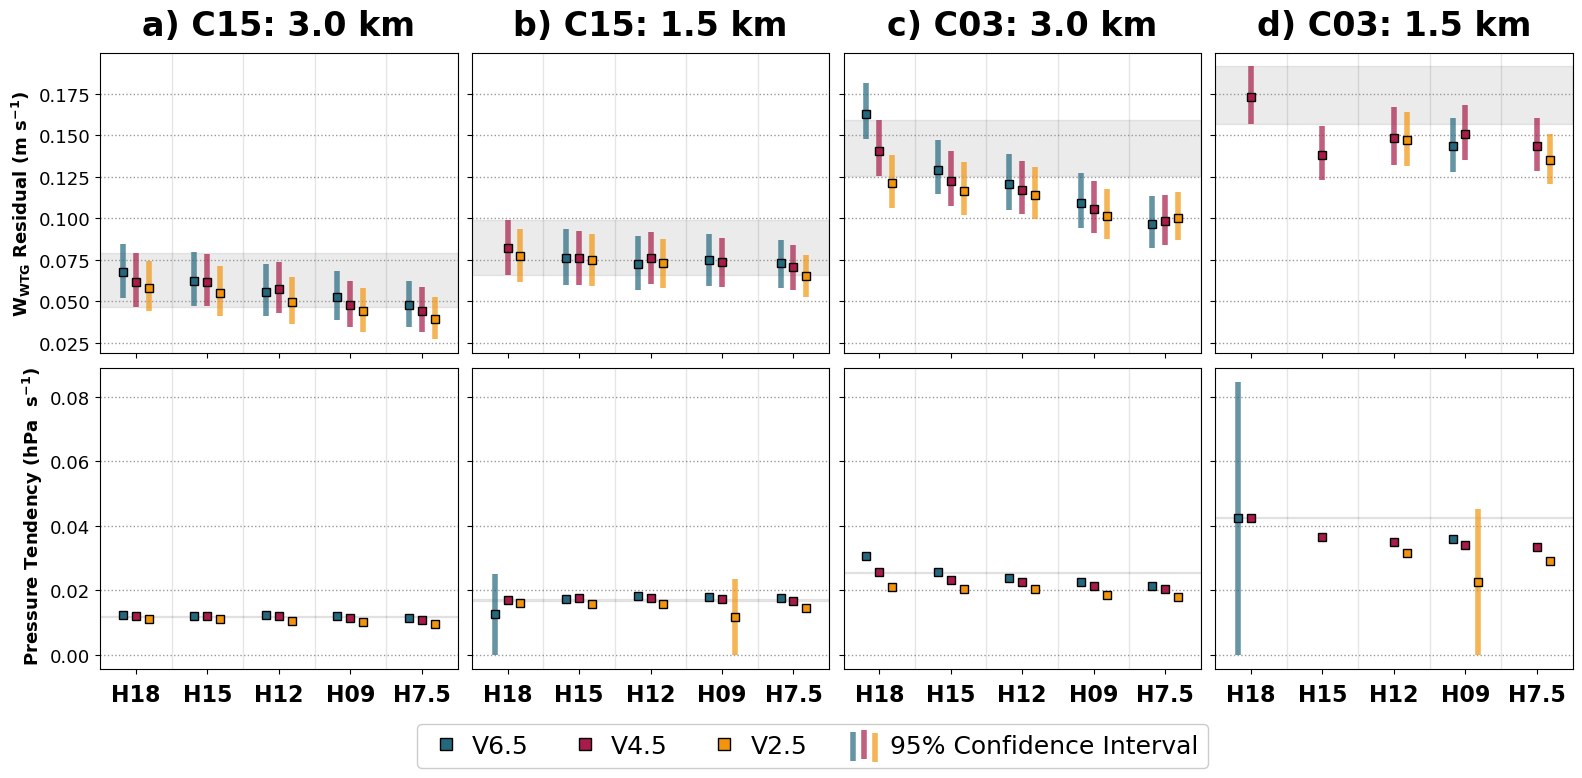

In [3]:
n = 36
max_val = 36
n_boot = 10000
indices = generate_bootstrap_indices(n, max_val, n_boot, seed=42)

interval=95




hloc = [18, 15, 12, 9, 7]
vloc = [6,4,2]
freq = [15, 15,3,3]#[15, 10, 3]



#################################################################

if len (freq) == 3:
    fig, axes = plt.subplots(2,3, figsize=(16, 8), sharey='row', sharex=True)
else:
    fig, axes = plt.subplots(2,4, figsize=(19, 8), sharey='row', sharex=True)


hloc_i = range(len(hloc))
vloc_i = range(len(vloc))
gridx, gridy = np.meshgrid(hloc_i, vloc_i)


colors = list(cmaps.pride([.2, .8, .6]))


ls     = '-'
lw     = 2
alpha  = 0.8
marker = 's'
ms     = 6

COUNT = 0
for ci, c in enumerate(freq):

    temp_table = np.zeros([2, len(hloc), len(vloc)]) 
    ci_table   = np.zeros([2,2, len(hloc), len(vloc)])
    for vi, v in enumerate(vloc):
        for hi, h in enumerate(hloc):

            try:

                if (COUNT == 0)| (COUNT == 2):
                    exp =  f"C{c:02d}_H{h:02d}_V{v}/"
                else:
                    exp =  f"C{c:02d}_H{h:02d}_V{v}_fine/"
            
                #try:
                path = os.path.join("/work/jessica.mcdonald/CM1_LETKF_2025/experiments/", exp)
                wtg = xr.open_dataset(f'{path}/balance.nc')
                stop = findnearest(wtg.time, 120)
                

                temp_table[0, hi, vi] = np.mean(wtg.wres_adjusted.values[:stop])
                temp_table[1, hi, vi] = np.mean(wtg.divc.values[:stop])/100


                # ci_table[0, hi, vi] = compute_ci_perc(bootstrap_fss_from_indices(wtg.wres_adjusted.values[:stop].mean(axis=0).flatten(), indices), interval)
                # ci_table[1, hi, vi] = compute_ci_perc(bootstrap_fss_from_indices(wtg.divc.values[:stop].mean(axis=0).flatten()/100, indices), interval)


                
                # ## the fss variable
                a_var= wtg.wres_adjusted.values[:stop].mean(axis=0)
            
                boot_metrics = bootstrap_singlevar(a_var, indices)
                results = get_universal_bca(a_var, boot_metrics, np.mean(a_var), mode='single_var', operation='single')
                ci_table[0, 0, hi, vi] = results['Value']['lower_bound']
                ci_table[0, 1, hi, vi] = results['Value']['upper_bound']


                a_var= wtg.divc.values[:stop].mean(axis=0)/100
            
                boot_metrics = bootstrap_singlevar(a_var, indices)
                results = get_universal_bca(a_var, boot_metrics, np.mean(a_var), mode='single_var', operation='single')
                ci_table[1, 0, hi, vi] = results['Value']['lower_bound']
                ci_table[1, 1, hi, vi] = results['Value']['upper_bound']


                wtg.close()
            except:
                pass
    COUNT +=1

    temp_table[temp_table == 0] = np.nan

    for i in range(2):
        axes[i, ci].grid(axis='y')
        shift = .18
        for vi, v in enumerate(vloc):
            name = rename(f'C03_H09_V{v}', version='V').split('-')[1]
    
            xoff = shift * (vi - 1)
            axes[i, ci].errorbar(np.array(hloc_i)+xoff, temp_table[i,:,vi], yerr=abs(ci_table[i,:,:,vi]-temp_table[i,:,vi]), marker='s', ms=0,mec='k', lw=0,color=colors[vi], elinewidth=4,capsize=0, label=name, alpha=0.7)
            axes[i, ci].plot(np.array(hloc_i)+xoff, temp_table[i,:,vi], color=colors[vi], ls=ls, marker=marker,markersize=ms,markeredgecolor='k', linewidth=0, alpha=1, label=name)

            if v == 4:
                conh = findnearest(hloc, 18)
                axes[i, ci].axhspan(ci_table[i,0,conh,vi],ci_table[i,1, conh,vi], alpha=0.08, color='k')#alpha=0.1, color=colors[vi])



for ax in axes.flatten():
    ax.set_xticks(hloc_i,[rename(f'C03_H{m:02d}_V4', version='H').split('-')[1] for m in hloc], weight='bold', fontsize=16)#, pad=10)
    ax.set_xlim(-0.5, len(hloc)-0.5)
    _=[ax.axvline(hl+.5, color='k', alpha=0.1, lw=1) for hl in hloc_i]
    ax.tick_params(axis='x', which='major', pad=7)


unit = r'm$\mathbf{^2}$ s$\mathbf{^{-2}}$'
labels = ['40 dBZ CRef eFSS',f'100 {unit} UH eFSS', 'Cold Pool Size Error\n'+r'(1000 km$\mathbf{^2}$)', ]

# set titles
for ci,c in enumerate(freq):
    if ci%2 == 0: grid = ': 3.0 km' 
    else: grid = ': 1.5 km'

    axes[0, ci].set_title(chr(ord('`')+ci+1)+') '+rename(f'C{c:02d}_H09_V4', version='CI')+grid, weight='bold', fontsize=24,  y=1.03)


plt.subplots_adjust(hspace=0.05, wspace=0.04)

labels = [r'W$\mathbf{_{WTG}}$ Residual (m s$\mathbf{^{-1}}$)', "dP\'/dt"+r'(hPa  s$\mathbf{^{-1}}$)']
axes[0,0].set_ylabel(r'W$\mathbf{_{WTG}}$ Residual (m s$\mathbf{^{-1}}$)', weight='bold')
axes[1,0].set_ylabel(r" Pressure Tendency (hPa  s$\mathbf{^{-1}}$)", weight='bold')

axes[0,0].scatter(-1.5, np.nanmean(temp_table[0]), marker='|', linewidth=4, s=200, color='w', alpha=0.7, label='95% Confidence Interval')
handles, labels =axes[0,0].get_legend_handles_labels()
new_handles,new_labels = [handles[0],handles[1],handles[2],(handles[3])], [labels[0], labels[1],labels[2], labels[3]]
leg=fig.legend(new_handles, new_labels, fontsize=18, scatterpoints=3, markerscale=1.5, loc='lower center', bbox_to_anchor=(0.5, -.03), ncol=4, columnspacing=1.5, handletextpad=.3, handlelength=1.5)
leg.legend_handles[3].set_facecolors(colors)



# Volume and Forecast Skill

In [4]:
import colorsys

def darken_rgba_color(r, g, b, a, factor=0.1):
    """
    Darkens an RGBA color by a specified factor (0.0 to 1.0).

    Args:
        r, g, b, a (float): The original color components in the range [0.0, 1.0].
        factor (float): The amount to darken the color (e.g., 0.1 for 10% darker).

    Returns:
        tuple: The new darkened RGBA color (r, g, b, a) in the range [0.0, 1.0].
    """
    # Convert RGB to HLS
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    # Decrease the lightness, ensuring it stays within [0.0, 1.0]
    # The new lightness is the original lightness times (1 - factor)
    l = max(0.0, min(1.0, l * (1.0 - factor)))

    # Convert back to RGB
    new_r, new_g, new_b = colorsys.hls_to_rgb(h, l, s)

    return new_r, new_g, new_b, a


def plot_reg_quick(ax, varx, vary, color):
    varx = varx[np.isnan(varx) == False]
    vary = vary[np.isnan(vary) == False]
    slope1, intercept1, rvalue1, pval, stderr = scipy.stats.linregress(varx, vary)
    a1x = np.linspace(np.nanmin(varx)-.001, np.nanmax(varx)+.001, 3)
    ax.plot(a1x, slope1*a1x+intercept1, color=color, linestyle='--',lw=2, alpha=1)
    return rvalue1, slope1



Text(0.5, 1.03, 'after 90 minutes of DA')

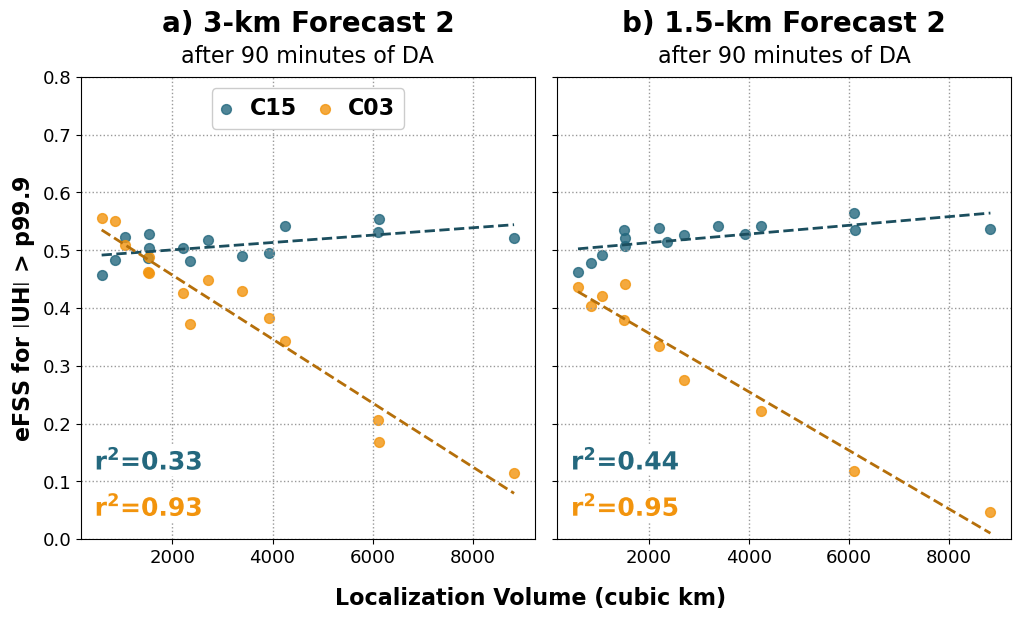

In [5]:


fig, axes = plt.subplots(1,2, figsize=(12,6), sharex=True, sharey=True)

fcsts = ['', '_fine']

colors = cmaps.pride([0.2, 0.6, 0.75])

for ci, cint in enumerate([15,3]):

    fpaths = sorted([f for f in glob.glob(f"/work/jessica.mcdonald/CM1_LETKF_2025/experiments/C{cint:02d}*") if len(os.path.basename(f)) == 10 ])

    temp = np.zeros((2, len(fpaths)*len(fcsts)))

    for fi,f in enumerate(fpaths):


        for fc, fcst in enumerate(fcsts):
            

            name = rename(os.path.basename(f), version='full')
                    
            h = float(name.split('-')[1][1:])
            v = float(name.split('-')[2][1:])
            volume = (4/3)*np.pi*v*h*h

            temp[0, fi + (fc*len(fpaths))] = volume
        
        
        
            var = 'UH'# allvar[i]
            thresh=99.9 #allthresh[i]
    
        
            try:
                ds = xr.open_dataset(os.path.join(f+fcst, f'fss_{var}.nc' ))
                neighborhoods = ds.SCALES.values*1000
                th_i = findnearest(ds.FCST_THLDS[0].values, thresh)
                n_i  = findnearest(neighborhoods, 24)
                CSI = np.mean(ds.EFSS[:,n_i, th_i].values)
                ds.close()
            except:
                CSI = np.nan
                temp[0, fi + (fc*len(fpaths))] = np.nan

            axes[fc].scatter(volume, CSI, marker = 'o', color=colors[ci], s=50, alpha=0.8, label=os.path.basename(f).split('_')[0])


            temp[1, fi + (fc*len(fpaths))] = CSI
            
             
    for fc in range(len(fcsts)):
        darkened_color = darken_rgba_color(*colors[ci], factor=0.25)
        
        r1,s1 = plot_reg_quick(axes[fc],temp[0, 0+len(fpaths)*(fc):len(fpaths)*(fc+1)], temp[1,0+len(fpaths)*(fc):len(fpaths)*(fc+1)], darkened_color)
        
        shift = .1 * ci
        axes[fc].text(.03, .15-shift, r'r$\mathbf{^2}$='+f'{r1**2:.2f}', transform=axes[fc].transAxes, fontsize=18, weight='bold',color=colors[ci],path_effects =[path_effects.Stroke(linewidth=10, foreground='w'),path_effects.Normal()])
       

for ax in axes.flatten():
    ax.grid()
    ax.set_ylim(0,0.8)
    
axes[0].set_ylabel(r'eFSS for $\mathbf{\left| {UH} \right|}$'+f' > p{thresh}',   weight='bold',fontsize=16)

handles, labels = axes[0].get_legend_handles_labels()
unique_items = dict(zip(labels, handles))
axes[0].legend(unique_items.values(), unique_items.keys(), loc='upper center', ncol=4,prop={'size':16, 'weight':'bold'} , columnspacing=1, handlelength=.5)


fig.text(0.5, 0.0, 'Localization Volume (cubic km)', weight='bold', fontsize=16, ha='center')

plt.subplots_adjust(hspace=0.05, wspace=0.05)

#axes[1].set_xlim(0.006, 0.038)
axes[0].set_title('a) 3-km Forecast 2', weight='bold',fontsize=20, y=1.08)
axes[1].set_title('b) 1.5-km Forecast 2', weight='bold',fontsize=20, y=1.08)

axes[0].text(0.5, 1.03, 'after 90 minutes of DA', fontsize=16, ha='center', transform=axes[0].transAxes)
axes[1].text(0.5, 1.03, 'after 90 minutes of DA', fontsize=16, ha='center', transform=axes[1].transAxes)


# FIGNAME = 'BothForecastRegression'
# plt.savefig(f'/work/jessica.mcdonald/PublicationFigures/FIG{FIGNAME}.png', dpi=300, bbox_inches='tight')

# Inf vs balance

In [34]:
def preprocess(ds, filename):
    # Extract time from filename (edit this!)
    time_str = filename.split("_")[-1].replace(".nc", "")
    time = (dt.datetime.strptime(filename.split("/")[-1].replace(".nc", "").replace('Inflation_', ''), '%Y-%m-%d_%H:%M:%S') - dt.datetime(2024,5,8,19,30)).seconds/60
    
    return ds.expand_dims(time=[time])

# files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
# ds = xr.open_mfdataset( files, combine="nested", concat_dim="time", preprocess=lambda ds: preprocess(ds, ds.encoding["source"]))

In [ ]:
# note: this takes almost 3 minutes to run

exps = [f'C{h:02d}_H15_V4' for h in [15,10,3]]
colors = cmaps.pride(np.linspace(.2, .8, len(exps)))


n = 36
max_index = 36
n_boot = 10000
indices = generate_bootstrap_indices(n, max_index, n_boot, seed=42)
interval = 95

vols = [589,848,1060,1508,1527,1532,2205,2356,2714,3393,3921,4241,6107,6126,8822]
hloc = [18,15,12,9,7]
vloc = [6, 4, 2]


df = pd.DataFrame()

for freq in [15, 3]:

    volume = []
    pres   = []
    adapt  = []
    #ci     = []
    for hi, h in enumerate(hloc):
        for vi, v in enumerate(vloc):
    
            exp = f'C{freq:02d}_H{h:02d}_V{v}'
            name = rename(exp, version='full')             
            hr = float(name.split('-')[1][1:])
            vr = float(name.split('-')[2][1:])
                
            files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
            ds = xr.open_mfdataset( files, combine="nested", concat_dim="time", preprocess=lambda ds: preprocess(ds, ds.encoding["source"]))
            
            wtg = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/balance.nc')
            stop = findnearest(wtg.time.values, 120)#+1


            #ci.extend([compute_ci_perc(bootstrap_fss_from_indices(wtg.divc.values[:stop].mean(axis=0).flatten()/100, indices), interval)])


            volume.extend([(4/3)*np.pi*vr*hr*hr])
            pres.extend([np.mean(wtg.divc.values[:stop])/100])
            adapt.extend([np.mean(ds.inflation.values)])
        
   # df = pd.DataFrame( data = {'p': wtg.divc.values[:stop].mean(axis=1)/100}, index = [dt.timedelta(minutes =t) for t in wtg.time.values[:stop]])
    #res = df.resample(dt.timedelta(seconds=int(exp.split('_')[0][1:])*60), label='right', closed='right').mean()

        #plt.scatter(np.mean(ds.inflation.values), np.mean(wtg.divc.values[:stop])/100, color=colors[ei])
    
            wtg.close()
            ds.close()
    df[f'vols_{freq}'] = volume
    df[f'pres_{freq}'] = pres
    df[f'adapt_{freq}'] = adapt
    #df[f'ci95_{freq}'] = ci

df_fine = pd.DataFrame()

for freq in [15, 3]:

    volume = []
    pres   = []
    adapt  = []
    #ci     = []
    for hi, h in enumerate(hloc):
        for vi, v in enumerate(vloc):
    
            try:
                exp = f'C{freq:02d}_H{h:02d}_V{v}_fine'
                name = rename(exp, version='full')             
                hr = float(name.split('-')[1][1:])
                vr = float(name.split('-')[2][1:])
                    
                files = sorted(glob.glob(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/Inflation*'))
                ds = xr.open_mfdataset( files, combine="nested", concat_dim="time", preprocess=lambda ds: preprocess(ds, ds.encoding["source"]))
                
                wtg = xr.open_dataset(f'/work/jessica.mcdonald/CM1_LETKF_2025/experiments/{exp}/balance.nc')
                stop = findnearest(wtg.time.values, 120)#+1


                #ci.extend([compute_ci_perc(bootstrap_fss_from_indices(wtg.divc.values[:stop].mean(axis=0).flatten()/100, indices), interval)])


                volume.extend([(4/3)*np.pi*vr*hr*hr])
                pres.extend([np.mean(wtg.divc.values[:stop])/100])
                adapt.extend([np.mean(ds.inflation.values)])
            except:
                volume.extend([np.nan])
                pres.extend([np.nan])
                adapt.extend([np.nan])
            
   # df = pd.DataFrame( data = {'p': wtg.divc.values[:stop].mean(axis=1)/100}, index = [dt.timedelta(minutes =t) for t in wtg.time.values[:stop]])
    #res = df.resample(dt.timedelta(seconds=int(exp.split('_')[0][1:])*60), label='right', closed='right').mean()

        #plt.scatter(np.mean(ds.inflation.values), np.mean(wtg.divc.values[:stop])/100, color=colors[ei])
    
            wtg.close()
            ds.close()
    df_fine[f'vols_{freq}'] = volume
    df_fine[f'pres_{freq}'] = pres
    df_fine[f'adapt_{freq}'] = adapt



Text(0, 0.5, 'Ensemble Mean\nPressure Tendency (hPa  s$\\mathbf{^{-1}}$)')

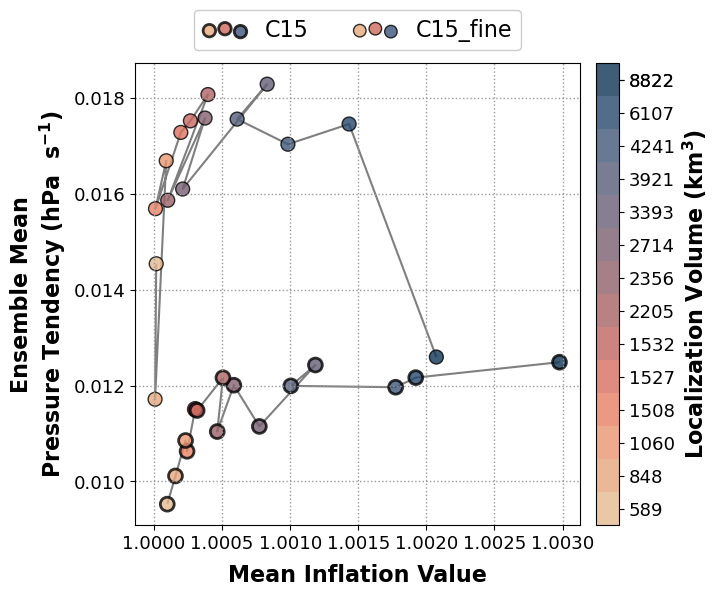

In [49]:
MYCI = 15

colors = cmaps.lipari(np.linspace(0.1,.85,15))[::-1]

cmap1 = LinearSegmentedColormap.from_list("CR",colors, 14)

mappable = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=14), cmap=cmap1)
mappable.set_array([])

fig,ax = plt.subplots(1,1, figsize=(7,6))

mycols = [colors[findnearest(vols, df.vols_3.loc[i])] for i in df.index]

if MYCI == 3:

    # plot the line
    df_sorted = df.sort_values(by='vols_3')
    ax.plot(df_sorted.adapt_3, df_sorted.pres_3, color='k', zorder=0, alpha=0.5)

    df_sortedf = df_fine.sort_values(by='vols_3')
    ax.plot(df_sortedf.adapt_3, df_sortedf.pres_3, color='k', zorder=0, alpha=0.5)

    # scatter plot
    ax.scatter(df.adapt_3, df.pres_3,   c= mycols, marker='o',s=100,ec='k',lw=2, label='C03', alpha=0.8)
    ax.scatter(df_fine.adapt_3, df_fine.pres_3,   c= mycols, marker='o',s=100,ec='k',label='C03_fine', alpha=0.8)#

else:
    # plot the line
    df_sorted = df.sort_values(by='vols_15')
    ax.plot(df_sorted.adapt_15, df_sorted.pres_15, color='k', zorder=0, alpha=0.5)

    df_sortedf = df_fine.sort_values(by='vols_15')
    ax.plot(df_sortedf.adapt_15, df_sortedf.pres_15, color='k', zorder=0, alpha=0.5)

    # scatter plot
    ax.scatter(df.adapt_15, df.pres_15,   c= mycols, marker='o',s=100,ec='k',lw=2, label='C15', alpha=0.8)
    ax.scatter(df_fine.adapt_15, df_fine.pres_15,   c= mycols, marker='o',s=100,ec='k',label='C15_fine', alpha=0.8)#

ax.grid()


cbar = fig.colorbar( mappable, ax=ax, alpha=0.8, pad=0.03)#, spacing='uniform', ticks = np.unique(df.vols_3))#, ticks=np.unique(df1.VOL))
cbar.set_label(r'Localization Volume (km$\mathbf{^3}$)', fontsize=16)
#cbar.set_ticks(ticks=[0, 3, 6,10, 14], labels=[vols[0],vols[3], vols[6],vols[10], vols[14]]);

cbar_ticks = np.array(np.arange(0, 15))
labels = [vols[i] for i in cbar_ticks]

cbar_ticks = np.concatenate([cbar_ticks[:-1] + 0.5, [13.5]])
cbar.set_ticks(ticks=cbar_ticks, labels=labels);



leg = plt.legend(scatterpoints=3, fontsize=16, markerscale=0.9, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.14))
leg.legend_handles[0].set_facecolors(cmaps.lipari([0.2,.6, .8])[::-1])
leg.legend_handles[1].set_facecolors(cmaps.lipari([0.2,.6, .8])[::-1])

ax.set_xlabel('Mean Inflation Value', fontsize=16, labelpad=8)
ax.set_ylabel('Ensemble Mean\n'+r'Pressure Tendency (hPa  s$\mathbf{^{-1}}$)', fontsize=16)

# FIGNAME = 'BalanceAndInf'
# plt.savefig(f'/work/jessica.mcdonald/PublicationFigures/FIG{FIGNAME}.png', dpi=300, bbox_inches='tight')

In [44]:
df_sorted = df.sort_values(by='vols_3')